In [142]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [143]:
df = pd.read_csv(r"C:\Users\Dev\OneDrive\Desktop\data\Datasets\data_for_eda.csv")

In [144]:
df = df.iloc[:,1:]

# Exploratory Data Analysis

In [145]:
print(df.head().to_string())

   loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade             emp_title emp_length home_ownership  annual_inc issue_d    loan_status         purpose                                  title    dti  delinq_2yrs earliest_cr_line  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc initial_list_status  out_prncp  out_prncp_inv   total_pymnt  total_pymnt_inv  total_rec_prncp  total_rec_int  total_rec_late_fee  recoveries  collection_recovery_fee last_pymnt_d  last_pymnt_amnt next_pymnt_d last_credit_pull_d  collections_12_mths_ex_med  mths_since_last_major_derog  policy_code application_type  acc_now_delinq  tot_coll_amt  tot_cur_bal  total_rev_hi_lim   19
0       5000         5000           4975.0   36 months     10.65       162.87     B        B2               UNKNOWN  10+ years           RENT     24000.0  Dec-11  Not Defaulter     credit_card                               Computer  27.65          0

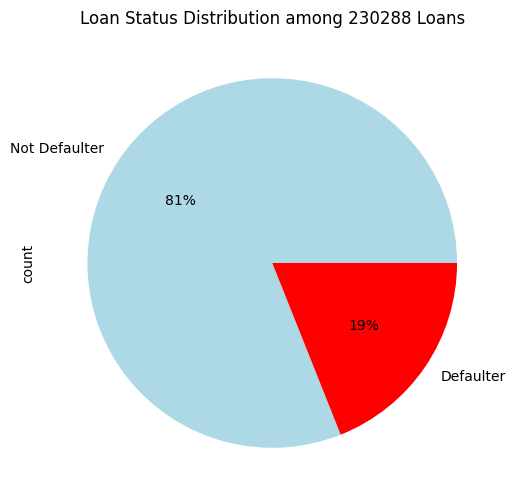

In [146]:

df.loan_status.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', figsize = (6,6), colors = ['lightblue', 'red'])
plt.title(f'Loan Status Distribution among {len(df)} Loans')
plt.show()


# 1 -  `Loan amount`
- We will describe the descriptive statistics of loan amount
- Will use histogram or frequency plot of loan amount versus customers 


In [147]:
df[['loan_amnt']].describe()

,loan_amnt
count,230288.000000
mean,13418.021022
std,8041.533088
min,500.000000
25%,7200.000000
50%,12000.000000
75%,18000.000000
max,35000.000000


In [148]:
pie_df = df[['loan_amnt']].describe().loc[['25%', '50%', '75%', 'max'],:]
pie_df

rng = [0,7200,12000,18000,35000,np.inf]
no_customers =[ ]
for i in range(len(rng)-2):

    if i == 3:
        no_customers.append( len( df[(df['loan_amnt'] >= rng[i]) ]   ) )
    else:
        no_customers.append( len( df[(df['loan_amnt'] >= rng[i]) & (df['loan_amnt'] < rng[i+1] )]   ) )
    
no_customers
pie_df['no_customers'] = no_customers


In [149]:
pie_df = pie_df.reset_index(drop = True)
pie_df['%total_cust'] = np.round(pie_df['no_customers'] *100 / np.sum(pie_df['no_customers']),2)
pie_df

,loan_amnt,no_customers,%total_cust
0,7200.0,56354,24.47
1,12000.0,57231,24.85
2,18000.0,54666,23.74
3,35000.0,62037,26.94


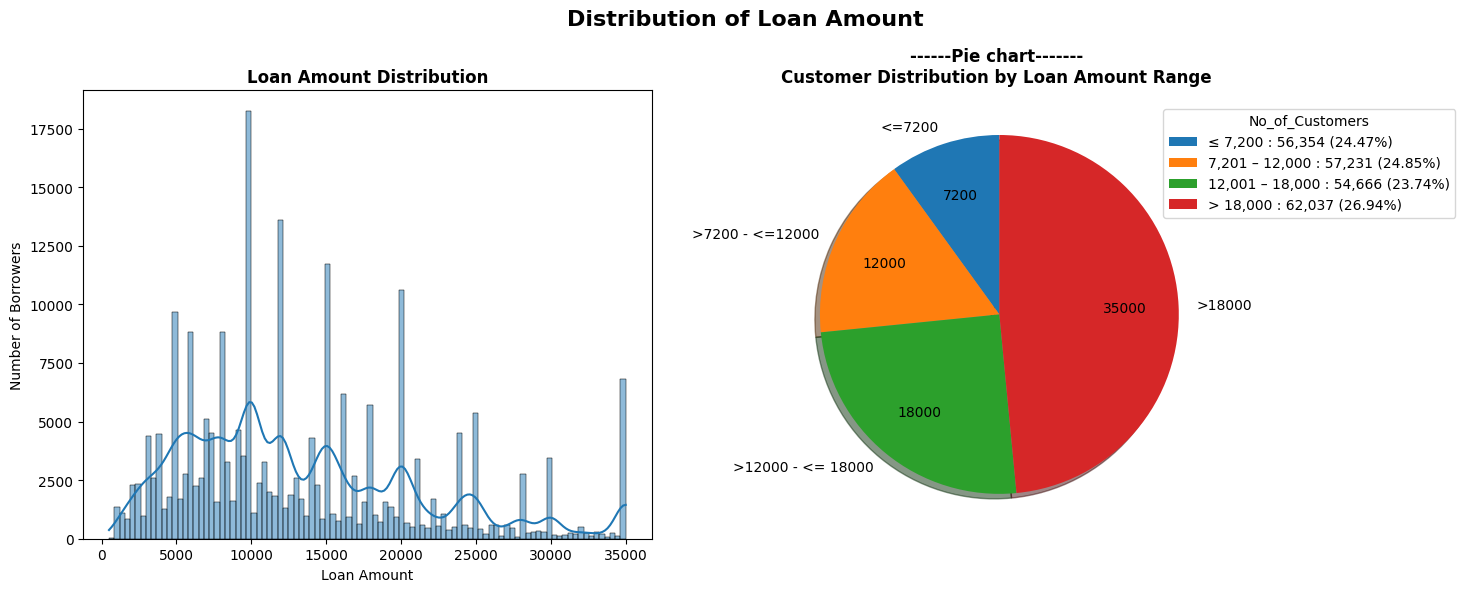

In [150]:
plt.figure(figsize=(15,6))

plt.suptitle("Distribution of Loan Amount", fontsize=16, fontweight="bold")


plt.subplot(1,2,1)
sns.histplot(df['loan_amnt'], kde= True)
plt.xlabel("Loan Amount")
plt.ylabel("Number of Borrowers")
plt.title("Loan Amount Distribution",fontweight='black')

plt.subplot(1,2,2)


plt.pie(x= pie_df.loan_amnt,
         labels= ['<=7200','>7200 - <=12000','>12000 - <= 18000', '>18000'],
        autopct=lambda p: f'{p*sum(pie_df.loan_amnt)/100:.0f}',
        startangle=90,
         pctdistance = 0.7,
        shadow = True,
        labeldistance = 1.1,)
plt.title("------Pie chart------- \nCustomer Distribution by Loan Amount Range ",fontweight='black')

plt.legend([ "≤ 7,200 : 56,354 (24.47%)", "7,201 – 12,000 : 57,231 (24.85%)", "12,001 – 18,000 : 54,666 (23.74%)", "> 18,000 : 62,037 (26.94%)" ]
           ,bbox_to_anchor= (0.85,0.7)
           ,title="No_of_Customers")
plt.tight_layout()
plt.show()

### Interpretation

- The **`loan_amnt`** feature exhibits a **positively (right) skewed distribution**, indicating that smaller loan amounts are more common than larger ones.
- Noticeable peaks occur at standard loan amounts such as **₹5,000, ₹10,000, ₹12,000, ₹15,000, ₹20,000, and ₹35,000**, suggesting that loans are generally sanctioned in predefined amounts.
- The **₹10,000** loan amount has the highest frequency, making it the most commonly approved loan amount in the dataset.
- As the loan amount increases, the number of borrowers gradually decreases, indicating that fewer customers apply for high-value loans.
- The distribution does not show any abnormal outliers, as the maximum loan amount of **₹35,000** appears to be the platform's upper lending limit rather than an erroneous observation.

# `Funded Amount`
- freq plot of no of customers having loan < their requested amount 

In [151]:
df.corr(numeric_only=True)['funded_amnt'][(df.corr(numeric_only=True)['funded_amnt'] > 0.15) | (df.corr(numeric_only=True)['funded_amnt'] < (-0.2))]

loan_amnt           0.997195
funded_amnt         1.000000
funded_amnt_inv     0.991933
int_rate            0.212110
installment         0.960062
annual_inc          0.348119
open_acc            0.204124
revol_bal           0.316778
total_acc           0.236656
total_pymnt         0.845150
total_pymnt_inv     0.841133
total_rec_prncp     0.780265
total_rec_int       0.680751
recoveries          0.189496
last_pymnt_amnt     0.564624
tot_cur_bal         0.317014
total_rev_hi_lim    0.349782
Name: funded_amnt, dtype: float64

### Interpretation of `funded_amnt`

- `funded_amnt` is **almost perfectly correlated** with `loan_amnt` (**r = 0.997**), indicating that borrowers typically receive nearly the full amount they request.
- It also has a **very strong positive correlation** with `funded_amnt_inv` (**r = 0.992**), suggesting that investor funding closely matches the total funded amount.
- A strong correlation with `installment` (**r = 0.960**) indicates that larger funded loans generally result in higher monthly installment payments.
- `annual_inc` has only a **moderate positive correlation** (**r = 0.348**), implying that higher-income borrowers tend to receive slightly larger loans, but income alone does not determine the funded amount.
- High correlations with variables such as `total_pymnt` and `total_rec_prncp` are expected because they are generated after the loan is issued and therefore represent **post-loan information**.

<Axes: >

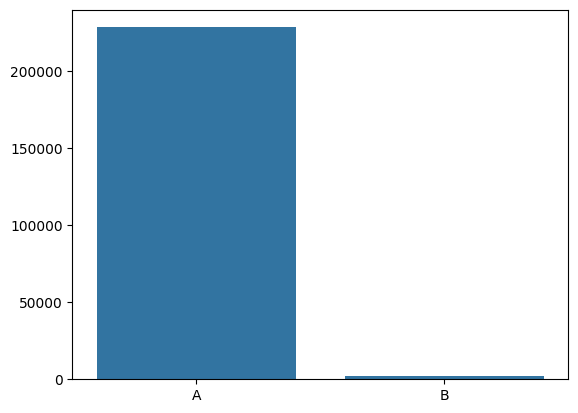

In [152]:
no_of_cust_with_less_fund_amnt = (df['funded_amnt'] < df['loan_amnt']).sum()
no_of_cust_with_equl_fund_amnt = len(df) - no_of_cust_with_less_fund_amnt
a = [no_of_cust_with_equl_fund_amnt,no_of_cust_with_less_fund_amnt]

sns.barplot(y = a, x = ['A','B'])

## Observation:
 The overwhelming majority of customers received the full funded amount equal to their requested loan amount. Only a small fraction of customers (Category B) were funded less than what they requested. This suggests that the lending platform rarely under-funds approved loans — once a loan is approved, it is funded at (or very near) the requested amount.

In [153]:
df['funded_amnt'].describe()

count    230288.000000
mean      13371.063190
std        8015.700642
min         500.000000
25%        7200.000000
50%       12000.000000
75%       18000.000000
max       35000.000000
Name: funded_amnt, dtype: float64

In [154]:
# Summary statistics of funded_amnt grouped by loan_status
df.groupby('loan_status')['funded_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Defaulter,43669.0,14425.554169,8333.117898,500.0,8000.0,12375.0,20000.0,35000.0
Not Defaulter,186619.0,13124.311431,7919.369515,500.0,7000.0,11500.0,18000.0,35000.0


In [155]:
# Compare average funded amount between defaulters and non-defaulters
df.groupby('loan_status')['funded_amnt'].mean()

loan_status
Defaulter        14425.554169
Not Defaulter    13124.311431
Name: funded_amnt, dtype: float64

## Observation:
 Defaulters tend to have slightly higher funded loan amounts than non-defaulters across all quartiles (mean: $14,425 vs $13,124; median: $12,375 vs $11,500). This suggests `funded_amnt` has a modest positive association with default risk — larger loans carry marginally higher risk — but the overlap between the two groups indicates funded amount alone is not a strong discriminator between defaulters and non-defaulters.

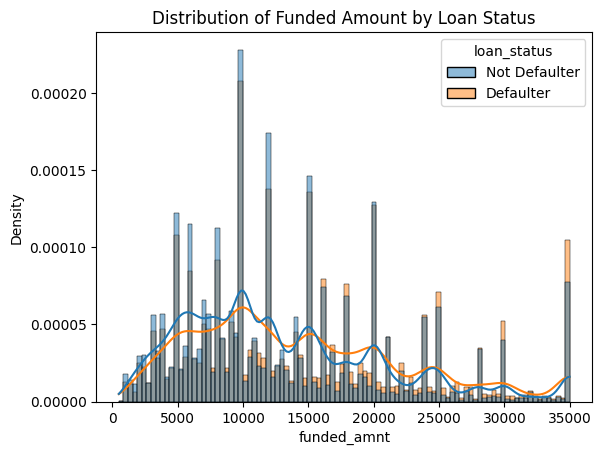

In [156]:
# Histogram/KDE - shows distribution shape overlap
sns.histplot(data=df, x='funded_amnt', hue='loan_status', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Funded Amount by Loan Status')
plt.show()

## Observation:
 The distribution of `funded_amnt` largely overlaps between defaulters and non-defaulters, especially in the $0–$30,000 range, confirming that funded amount alone is a weak discriminator of default risk. However, at the higher end (loans near the $35,000 cap), defaulters show a visibly higher density than non-defaulters — consistent with the earlier finding that defaulters have slightly higher average and median funded amounts. This suggests loan amount may add marginal predictive value primarily for larger loans, but is not a strong standalone risk indicator.

In [157]:
bins = [0, 10000, 20000, 30000, 35000]
labels = ['<10k', '10k-20k', '20k-30k', '30k+']
df['funded_amnt_bin'] = pd.cut(df['funded_amnt'], bins=bins, labels=labels)

pd.crosstab(df['funded_amnt_bin'], df['loan_status'], normalize='index') * 100

loan_status,Defaulter,Not Defaulter
funded_amnt_bin,,
<10k,16.688555,83.311445
10k-20k,19.623001,80.376999
20k-30k,22.994016,77.005984
30k+,24.414751,75.585249


# Funded amount by Investor

In [158]:
df['funded_amnt_inv'].describe()

count    230288.000000
mean      13239.461497
std        8054.568175
min           0.000000
25%        7000.000000
50%       11750.000000
75%       18000.000000
max       35000.000000
Name: funded_amnt_inv, dtype: float64

In [159]:
# How many loans have zero investor funding?
zero_inv = df[df['funded_amnt_inv'] == 0]
print(len(zero_inv))
zero_inv[['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'loan_status']].head(10)

233


,loan_amnt,funded_amnt,funded_amnt_inv,loan_status
36278,1775,1775,0.0,Not Defaulter
36282,7500,7500,0.0,Not Defaulter
36283,4000,4000,0.0,Not Defaulter
36286,3200,2100,0.0,Not Defaulter
36287,7500,7500,0.0,Not Defaulter
36289,7000,6100,0.0,Not Defaulter
36296,7500,4750,0.0,Not Defaulter
36310,5600,4300,0.0,Not Defaulter
36311,7500,4800,0.0,Not Defaulter
36313,7500,5550,0.0,Not Defaulter


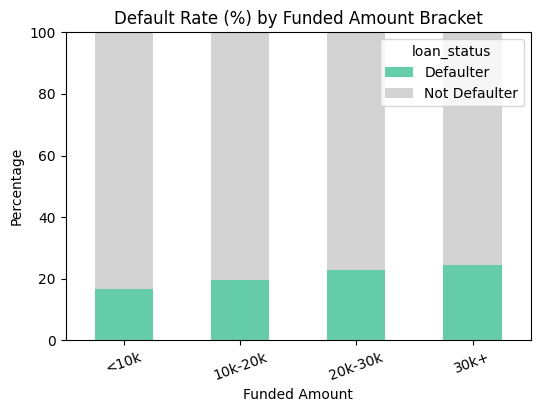

In [160]:
funded_status = (
    pd.crosstab(
        df['funded_amnt_bin'],
        df['loan_status'],
        normalize='index'
    ) * 100
)

funded_status = funded_status[['Defaulter', 'Not Defaulter']]

funded_status.plot(
    kind='bar',
    stacked=True,
    color=['mediumaquamarine', 'lightgray'],
    figsize=(6,4)
)

plt.title('Default Rate (%) by Funded Amount Bracket')
plt.xlabel('Funded Amount')
plt.ylabel('Percentage')
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.show()

In [161]:
funded_status

loan_status,Defaulter,Not Defaulter
funded_amnt_bin,,
<10k,16.688555,83.311445
10k-20k,19.623001,80.376999
20k-30k,22.994016,77.005984
30k+,24.414751,75.585249


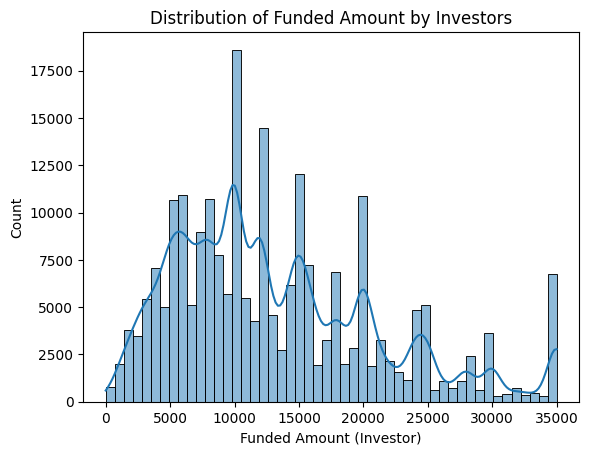

In [162]:
# Distribution plot
sns.histplot(df['funded_amnt_inv'], kde=True, bins=50)
plt.title('Distribution of Funded Amount by Investors')
plt.xlabel('Funded Amount (Investor)')
plt.show()

**Observation:** The distribution of `funded_amnt_inv` is right-skewed and multi-modal, with strong clustering around round numbers ($5k, $10k, $15k, $20k) and a visible spike at the $35,000 platform cap. The shape closely mirrors the `funded_amnt` distribution, suggesting investor funding nearly always matches the platform-approved amount. A small subset of loans show $0 investor funding, which warrants separate investigation as a potential edge case or data quality issue.

In [163]:
# Are these two columns ever different?
df['inv_funding_gap'] = df['funded_amnt'] - df['funded_amnt_inv']
df['inv_funding_gap'].describe()

# How many loans have a gap?
(df['inv_funding_gap'] != 0).sum()

np.int64(44934)

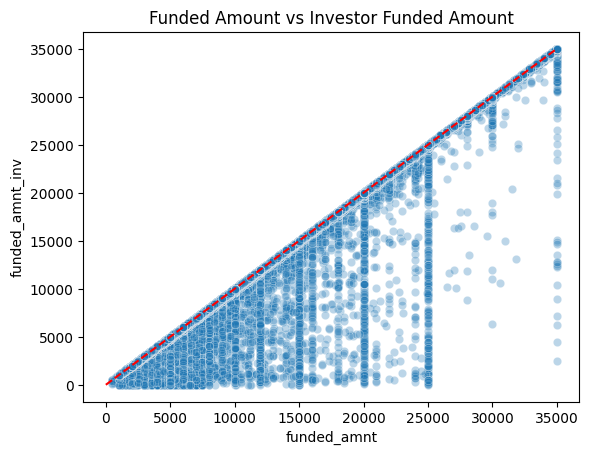

In [164]:
# Scatter plot - most points should fall on the diagonal if they match
sns.scatterplot(data=df, x='funded_amnt', y='funded_amnt_inv', alpha=0.3)
plt.plot([0, 35000], [0, 35000], color='red', linestyle='--')  # reference line
plt.title('Funded Amount vs Investor Funded Amount')
plt.show()

**Observation:** Approximately 19.5% of loans (44,934 out of 230,288) show a gap between `funded_amnt` and `funded_amnt_inv`, with investor funding always falling at or below the approved funded amount (never above), confirming the expected one-directional relationship. The gap widens noticeably for larger loan amounts, suggesting bigger loans are harder to fully fund through investor participation alone. This indicates `funded_amnt_inv` and the derived `inv_funding_gap` carry meaningful, non-redundant information and should be explored further (e.g., against `loan_status` and `grade`) rather than treated as a duplicate of `funded_amnt`.

In [165]:
df['inv_funding_gap_pct'] = (df['inv_funding_gap'] / df['funded_amnt']) * 100
df.groupby('loan_status')['inv_funding_gap_pct'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Defaulter,43669.0,1.525139,10.048978,0.0,0.0,0.0,0.0,100.0
Not Defaulter,186619.0,1.180745,8.166331,0.0,0.0,0.0,0.0,100.0


## TERMS


In [166]:
# Value counts
df['term'].value_counts()

# As percentages
df['term'].value_counts(normalize=True) * 100

term
36 months    78.632842
60 months    21.367158
Name: proportion, dtype: float64

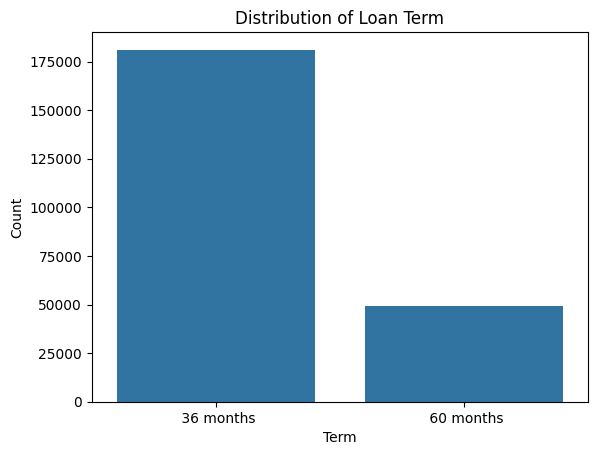

In [167]:
sns.countplot(data=df, x='term')
plt.title('Distribution of Loan Term')
plt.xlabel('Term')
plt.ylabel('Count')
plt.show()

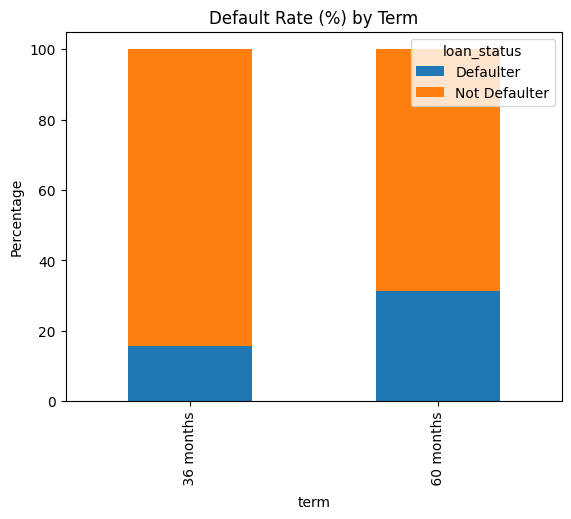

In [168]:
# Stacked percentage bar — often clearer for comparing default rate across terms
pct_table = pd.crosstab(df['term'], df['loan_status'], normalize='index') * 100
pct_table.plot(kind='bar', stacked=True)
plt.title('Default Rate (%) by Term')
plt.ylabel('Percentage')
plt.show()

**Observation:** Loan term is heavily imbalanced, with 78.6% of loans on a 36-month term and 21.4% on a 60-month term. However, term shows a strong relationship with default risk: approximately 32% of 60-month loans end in default compared to only ~16% of 36-month loans — roughly double the default rate. This makes `term` one of the stronger predictors of default risk identified so far in this EDA, considerably more discriminative than `funded_amnt` or `funded_amnt_inv`.

## Intrest Rate

In [169]:
df['int_rate'].describe()

count    230288.000000
mean         13.778540
std           4.367483
min           5.420000
25%          10.740000
50%          13.650000
75%          16.400000
max          26.060000
Name: int_rate, dtype: float64

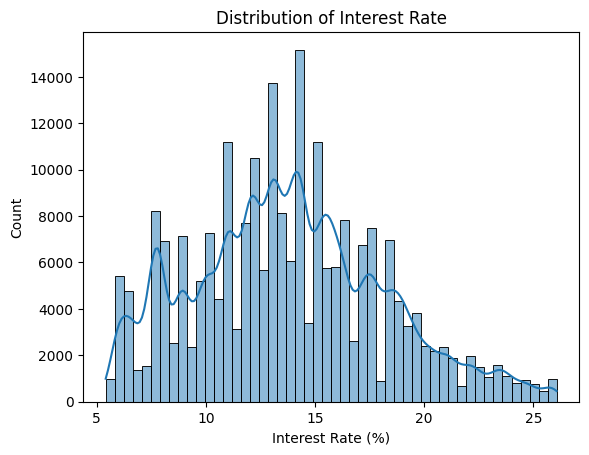

In [170]:
sns.histplot(df['int_rate'], kde=True, bins=50)
plt.title('Distribution of Interest Rate')
plt.xlabel('Interest Rate (%)')
plt.show()

**Observation:** Interest rates range from 5.42% to 26.06%, with a mean of 13.78% and median of 13.65%, indicating a fairly symmetric distribution with a mild right skew. The distribution shows several distinct peaks, likely corresponding to discrete sub-grade rate tiers (A1–G5) rather than a smooth continuum. The bulk of loans are priced between 8% and 18%, with a thinning tail beyond 20% representing the smaller pool of high-risk borrowers.

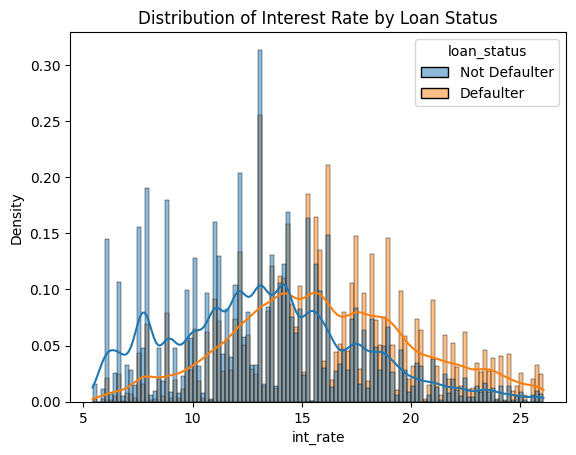

In [171]:
sns.histplot(data=df, x='int_rate', hue='loan_status', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Interest Rate by Loan Status')
plt.show()

**Observation:** Interest rate shows the clearest separation between defaulters and non-defaulters of any variable examined so far. Non-defaulters are concentrated in the lower interest rate range (8-13%), while defaulters are shifted notably higher (14-18% peak), with defaulters dominating the distribution beyond ~20%. This continuous, monotonic shift confirms that `int_rate` — which directly encodes the lender's risk assessment at issuance — is one of the strongest standalone predictors of default risk in the dataset, considerably stronger than `funded_amnt`, `funded_amnt_inv`, or even `term`.

In [172]:
# Correlation
df[['int_rate', 'loan_amnt', 'funded_amnt']].corr()

,int_rate,loan_amnt,funded_amnt
int_rate,1.000000,0.210193,0.212110
loan_amnt,0.210193,1.000000,0.997195
funded_amnt,0.212110,0.997195,1.000000


In [173]:
# Binned view - average interest rate by loan amount bracket
bins = [0, 5000, 10000, 15000, 20000, 25000, 30000, 35000]
labels = ['<5k', '5-10k', '10-15k', '15-20k', '20-25k', '25-30k', '30-35k']
df['funded_amnt_bin'] = pd.cut(df['funded_amnt'], bins=bins, labels=labels)

df.groupby('funded_amnt_bin')['int_rate'].mean()

C:\Users\Dev\AppData\Local\Temp\ipykernel_24100\1550002083.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('funded_amnt_bin')['int_rate'].mean()


funded_amnt_bin
<5k       13.270546
5-10k     12.934990
10-15k    13.514561
15-20k    14.280652
20-25k    14.617070
25-30k    15.937649
30-35k    17.136465
Name: int_rate, dtype: float64

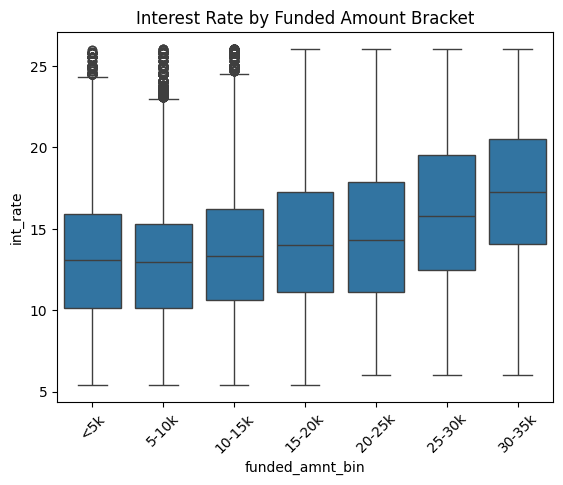

In [174]:
sns.boxplot(data=df, x='funded_amnt_bin', y='int_rate')
plt.title('Interest Rate by Funded Amount Bracket')
plt.xticks(rotation=45)
plt.show()

**Observation:** Interest rate shows only a weak correlation with loan amount (`loan_amnt`: 0.21, `funded_amnt`: 0.21), confirming that loan size is a minor factor in rate-setting compared to credit grade. However, a mild upward trend is still visible: average interest rate rises steadily from ~13.3% for loans under $5,000 to ~17.1% for loans between $30,000-$35,000, with the spread of rates also widening for larger loan brackets. As expected, `loan_amnt` and `funded_amnt` are nearly perfectly correlated (0.997), confirming these columns carry redundant information.

## Installment

In [175]:
df['installment'].describe()


count    230288.000000
mean        415.313686
std         243.426474
min          15.670000
25%         237.497500
50%         363.990000
75%         543.675000
max        1408.130000
Name: installment, dtype: float64

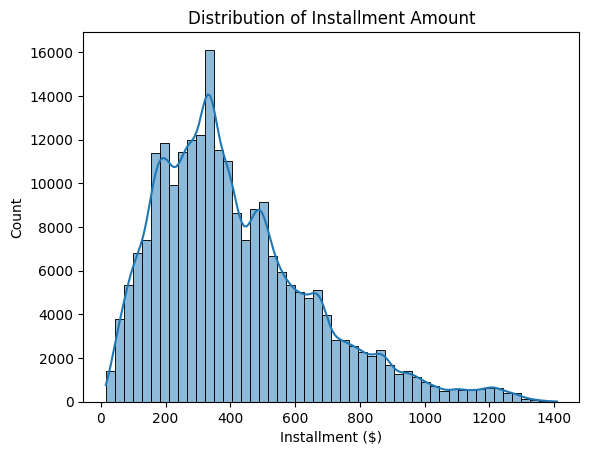

In [176]:
sns.histplot(df['installment'], kde=True, bins=50)
plt.title('Distribution of Installment Amount')
plt.xlabel('Installment ($)')
plt.show()

**Observation:** Installment amount is right-skewed (mean $415 vs median $364), consistent with the right-skewed distribution of `funded_amnt`. Most loans carry a monthly installment between $100-$500, with a peak around $300-$350, aligning with the most common loan amount bracket (~$10,000). The long right tail beyond $700 represents large loans on shorter terms, which produce proportionally higher monthly payments.

                  count        mean         std    min     25%     50%  \
loan_status                                                              
Defaulter       43669.0  438.740559  245.955166  15.91  262.91  389.21   
Not Defaulter  186619.0  409.831779  242.505092  15.67  231.92  357.35   

                   75%      max  
loan_status                      
Defaulter      570.540  1408.13  
Not Defaulter  535.685  1408.13  


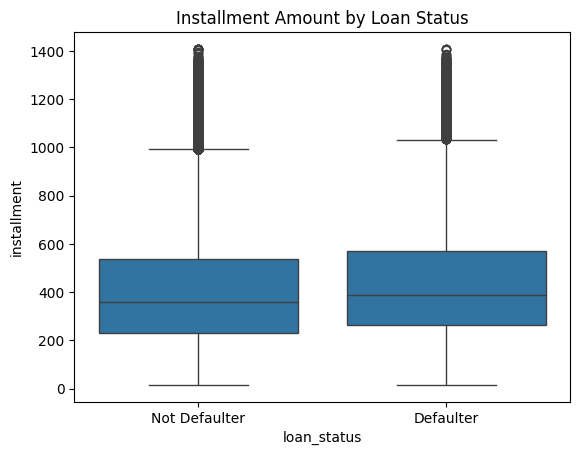

In [177]:
print(df.groupby('loan_status')['installment'].describe())
sns.boxplot(data=df, x='loan_status', y='installment')
plt.title('Installment Amount by Loan Status')
plt.show()

**Observation:** Defaulters show a modestly higher installment amount than non-defaulters across all quartiles (mean: $438.74 vs $409.83; median: $389.21 vs $357.35), a difference of roughly 7-9%. However, the boxplots show substantial overlap between the two groups, indicating installment alone is a weaker discriminator of default risk compared to `int_rate` or `term`. This is expected, since installment is mathematically derived from funded amount, interest rate, and term — combining a strong risk signal (rate, term) with a weak one (loan amount), which dilutes its overall discriminative power.

             installment  funded_amnt  int_rate
installment     1.000000     0.960062  0.201228
funded_amnt     0.960062     1.000000  0.212110
int_rate        0.201228     0.212110  1.000000


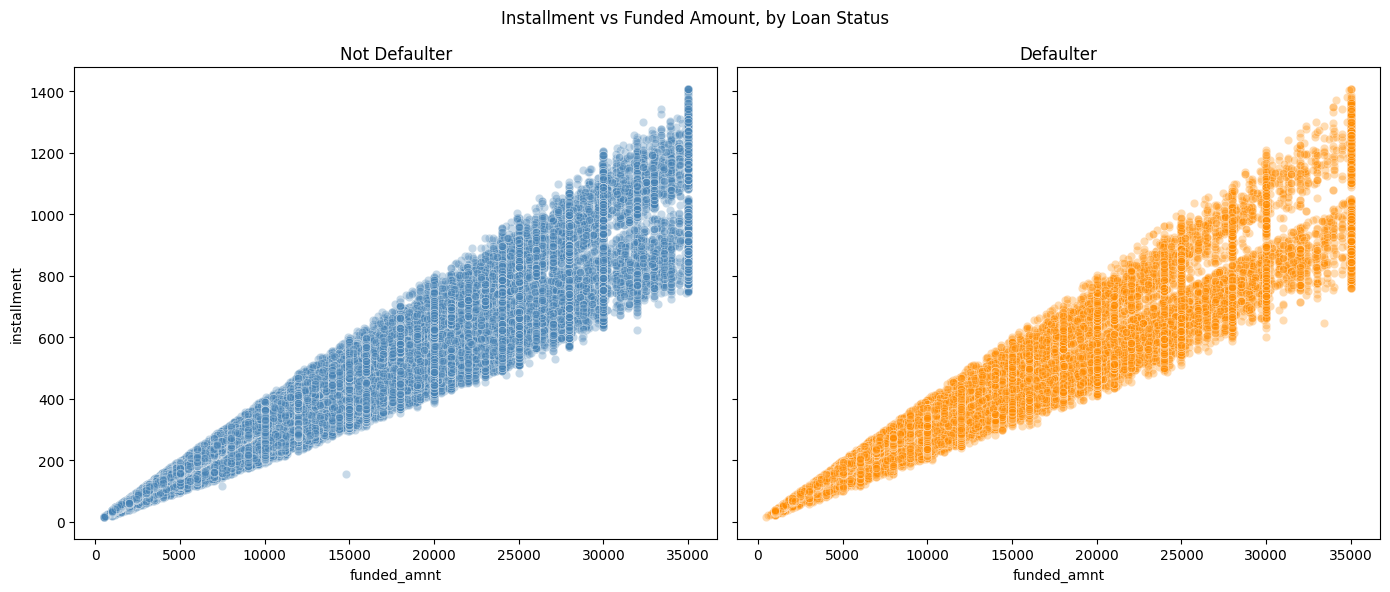

In [178]:
print(df[['installment', 'funded_amnt', 'int_rate']].corr())
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(data=df[df['loan_status']=='Not Defaulter'], x='funded_amnt', y='installment', alpha=0.3, color='steelblue', ax=axes[0])
axes[0].set_title('Not Defaulter')

sns.scatterplot(data=df[df['loan_status']=='Defaulter'], x='funded_amnt', y='installment', alpha=0.3, color='darkorange', ax=axes[1])
axes[1].set_title('Defaulter')

plt.suptitle('Installment vs Funded Amount, by Loan Status')
plt.tight_layout()
plt.show()

**Observation:** Installment is almost entirely driven by funded amount (correlation: 0.96) rather than interest rate (correlation: 0.20), confirming that loan size — not pricing — is the dominant factor in determining the monthly payment. The side-by-side scatter plots show no meaningful structural difference between defaulters and non-defaulters in the installment-vs-funded-amount relationship; both groups follow the same diagonal pattern. This explains why `installment` showed only a modest difference between loan statuses earlier: it is mathematically dominated by `funded_amnt` (a weak default predictor) rather than `int_rate` (a strong one), diluting its overall discriminative power.

## Grade & Sub Grade

grade
A    39052
B    70523
C    58501
D    36626
E    16863
F     6873
G     1850
Name: count, dtype: int64


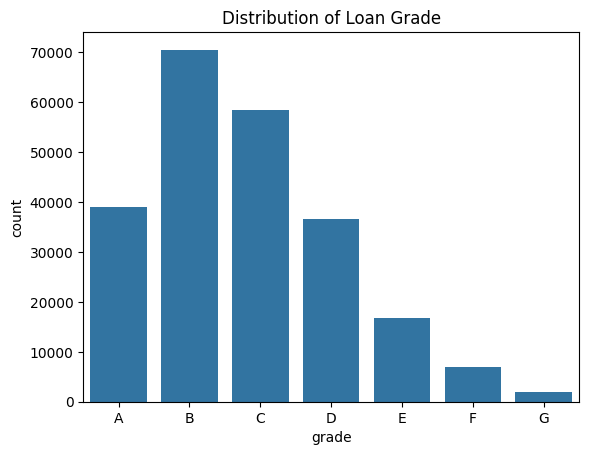

In [179]:
print(df['grade'].value_counts().sort_index())
sns.countplot(data=df, x='grade', order=sorted(df['grade'].unique()))
plt.title('Distribution of Loan Grade')
plt.show()

**Observation:** Loan grade distribution is concentrated in the B and C tiers (30.6% and 25.4% respectively), which together account for over half of all loans. The distribution declines steadily from B through G, with grade G (riskiest) representing less than 1% of loans. Notably, grade A (safest) is less common than both B and C, suggesting the platform's typical borrower profile skews toward "average risk" rather than prime credit applicants. The small sample size for E, F, and G grades (combined ~11%) means default-rate estimates for these tiers should be interpreted with some caution due to higher variance.

sub_grade
A1     5462
A2     5712
A3     6690
A4    10273
A5    10915
B1    11186
B2    13609
B3    17024
B4    15686
B5    13018
C1    13531
C2    12878
C3    11412
C4    10690
C5     9990
D1     9019
D2     8267
D3     7232
D4     6661
D5     5447
E1     4078
E2     4031
E3     3327
E4     2939
E5     2488
F1     1963
F2     1563
F3     1416
F4     1077
F5      854
G1      624
G2      453
G3      304
G4      242
G5      227
Name: count, dtype: int64


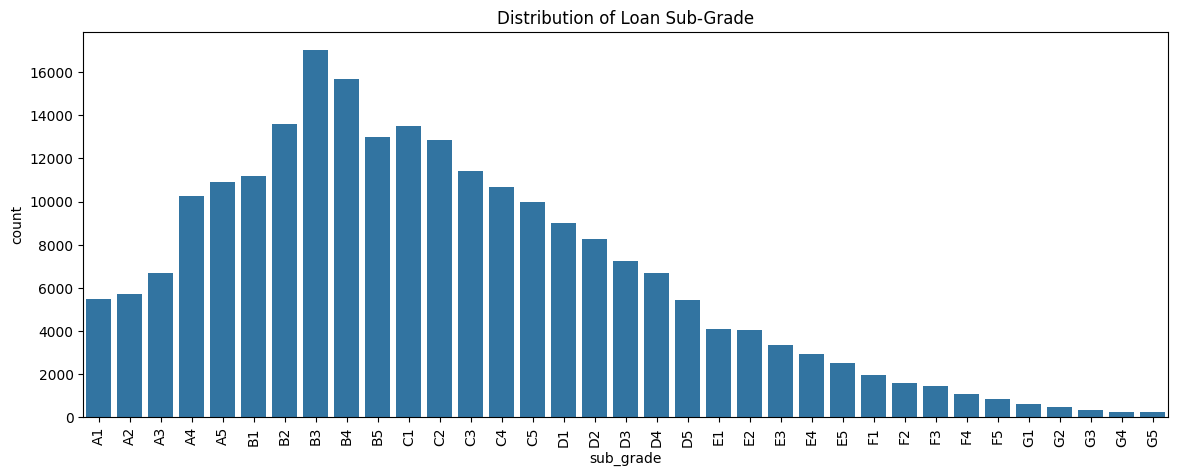

In [180]:
print(df['sub_grade'].value_counts().sort_index())
plt.figure(figsize=(14,5))
sns.countplot(data=df, x='sub_grade', order=sorted(df['sub_grade'].unique()))
plt.title('Distribution of Loan Sub-Grade')
plt.xticks(rotation=90)
plt.show()

**Observation:** Sub-grade distribution forms a smooth, continuous curve peaking at B3 (~16,800 loans), consistent with the grade-level finding that B and C are the most common risk tiers. The distribution declines steadily into the E, F, and G sub-grades, which each represent a very small fraction of total loans. Notably, within-grade sub-tiers are not evenly distributed — for example, A4 and A5 have nearly double the count of A1 and A2 — suggesting borrowers cluster toward the riskier end within each grade band rather than spreading evenly across sub-grades.

loan_status  Defaulter  Not Defaulter
grade                                
A             6.499027      93.500973
B            13.224055      86.775945
C            20.898788      79.101212
D            27.453175      72.546825
E            35.124236      64.875764
F            40.622727      59.377273
G            43.729730      56.270270


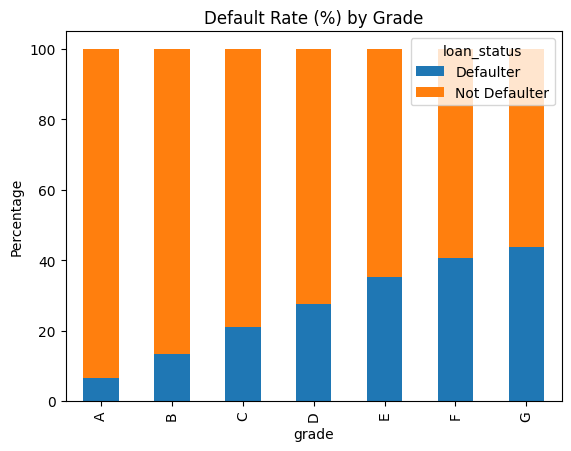

In [181]:
pct_table = pd.crosstab(df['grade'], df['loan_status'], normalize='index') * 100
print(pct_table)

pct_table.plot(kind='bar', stacked=True)
plt.title('Default Rate (%) by Grade')
plt.ylabel('Percentage')
plt.show()

**Observation:** Loan grade shows a perfectly monotonic relationship with default rate, rising from 6.5% for grade A to 43.7% for grade G — nearly a 7x increase in risk from the safest to riskiest tier. This is the strongest, cleanest signal identified across the entire EDA, far exceeding the discriminative power of `term` (~2x difference) or `funded_amnt` (~1.1x difference). Given that `grade` directly drives `int_rate` (confirmed by their near-perfect relationship), grade should be treated as the primary risk-tier variable in any subsequent modeling, with `int_rate` serving as its continuous counterpart.

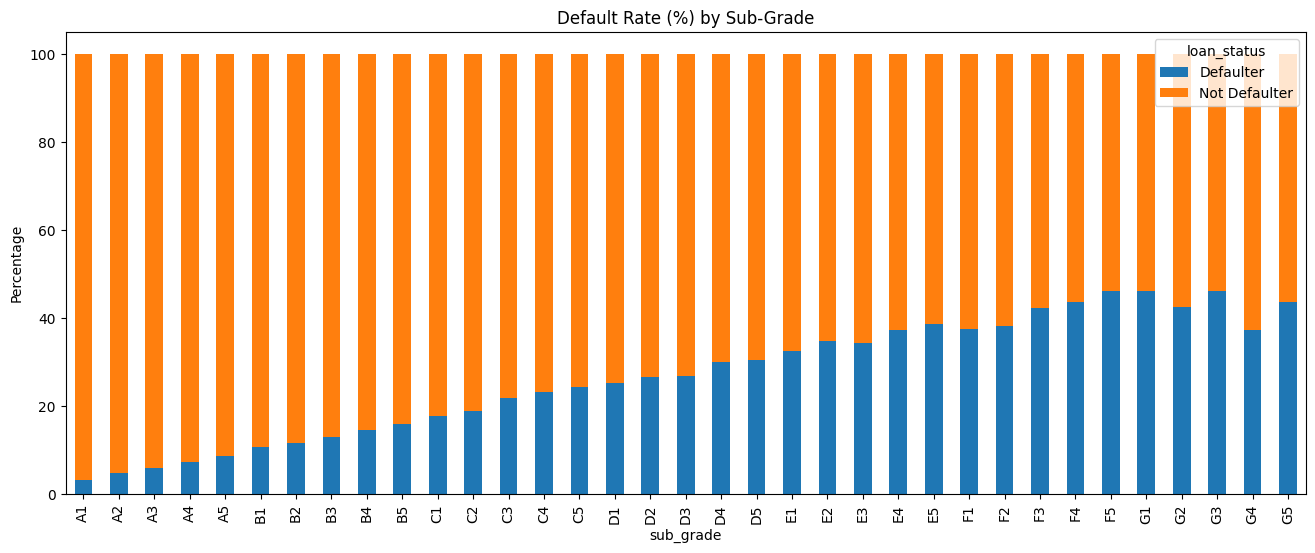

In [182]:
sub_pct_table = pd.crosstab(df['sub_grade'], df['loan_status'], normalize='index') * 100

sub_pct_table.plot(kind='bar', stacked=True, figsize=(16,6))
plt.title('Default Rate (%) by Sub-Grade')
plt.ylabel('Percentage')
plt.xticks(rotation=90)
plt.show()

**Observation:** Sub-grade shows a near-perfectly monotonic increase in default rate from A1 (~3-4%) to the G-tier sub-grades (~40-46%), mirroring and refining the grade-level pattern at finer resolution. The climb is smooth across grade boundaries, confirming sub-grade behaves as a continuous risk spectrum rather than 7 disconnected categories. A slight flattening is visible in the F-G range, suggesting diminishing discriminative power among the riskiest sub-grades — likely also influenced by their very small sample sizes (e.g., G4 has only 242 loans), making those specific estimates less reliable.

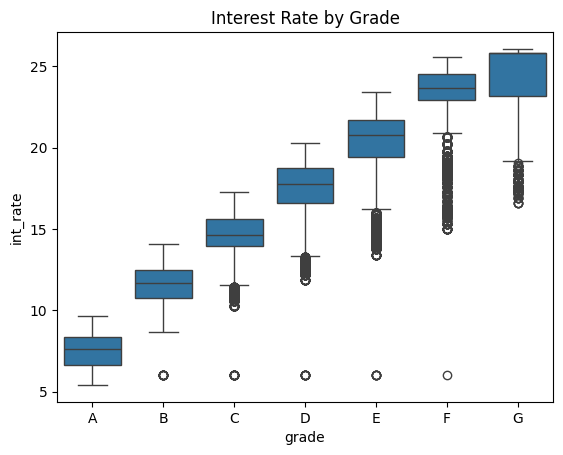

In [183]:
sns.boxplot(data=df, x='grade', y='int_rate', order=sorted(df['grade'].unique()))
plt.title('Interest Rate by Grade')
plt.show()

**Observation:** Interest rate increases in near-lockstep with loan grade, climbing from a median of ~7.5% for grade A to ~25% for grade G. Grades A through E show distinct, largely non-overlapping rate ranges, confirming that grade almost fully determines the rate band assigned to a loan. However, grades F and G show substantial overlap, indicating the rate distinction between the two riskiest tiers is comparatively small. This confirms that `grade` and `int_rate` are highly redundant variables — both encode essentially the same underlying risk assessment, with `grade` as the discrete/categorical version and `int_rate` as its continuous counterpart.

## Empolyment Length

['10+ years' '< 1 year' '3 years' '9 years' '4 years' '5 years' '1 year'
 '6 years' '2 years' '7 years' '8 years' 'UNKNOWN']
emp_length
10+ years    68674
2 years      21602
< 1 year     19285
3 years      18730
5 years      16781
1 year       15544
4 years      14911
6 years      13821
7 years      13010
8 years      10685
9 years       8627
UNKNOWN       8618
Name: count, dtype: int64


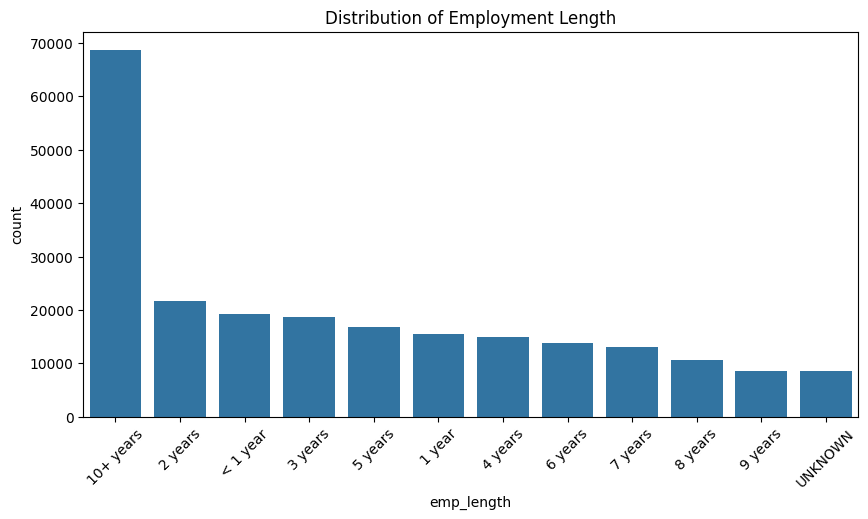

In [184]:
print(df['emp_length'].unique())
print(df['emp_length'].value_counts())
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='emp_length', order=df['emp_length'].value_counts().index)
plt.title('Distribution of Employment Length')
plt.xticks(rotation=45)
plt.show()

**Observation:** Employment length is heavily skewed toward "10+ years" (≈30% of all loans), making it by far the most common category — nearly 3x larger than the next group. The distribution then declines from short-tenure categories (1-3 years) through longer tenures, with a small dip just before the "10+ years" jump (likely a self-reporting/rounding effect, where borrowers near the 10-year mark round up). An "UNKNOWN" category accounts for ~3.7% of loans, representing borrowers with unreported employment length, which may itself carry predictive signal worth investigating against `loan_status`.

In [185]:
print(df['emp_length'].isnull().sum())
print(df['emp_length'].isnull().sum() / len(df) * 100)

0
0.0


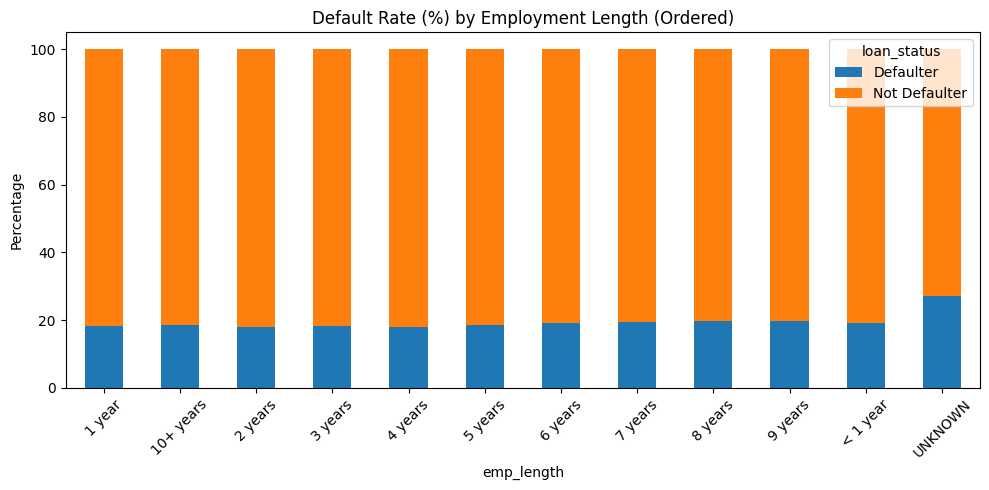

In [186]:
order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years',
         '6 years', '7 years', '8 years', '9 years', '10+ years']


pct_table = pd.crosstab(df['emp_length'], df['loan_status'], normalize='index') * 100
pct_table.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Default Rate (%) by Employment Length (Ordered)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Employment length shows no meaningful relationship with default rate — every category, from "< 1 year" to "10+ years," shows a default rate hovering around 18-20%, with no visible monotonic trend. This is in sharp contrast to variables like `grade` (6.5%-43.7% range) or `term` (~16%-32% range), confirming that job tenure is a weak/negligible standalone predictor of loan default in this dataset.

# Home Ownership

In [187]:
df['home_ownership' ].value_counts()
df.loc[df['home_ownership'].isin(['OTHER','NONE','ANY']), 'loan_status'].value_counts()

loan_status
Not Defaulter    182
Defaulter         46
Name: count, dtype: int64

### Reason for Renaming to "UNSPECIFIED"

- *OTHER*, *NONE*, and *ANY* are rare categories (~0.1% of data).  
- They don’t represent clear ownership types.  
- Merging them into **UNSPECIFIED** reduces noise and improves clarity in modeling.


In [188]:
df.loc[df['home_ownership'].isin(['OTHER','NONE','ANY']), 'home_ownership'] = 'UNSPECIFIED'

The following table shows the count of home ownership and type of home ownership -----

 loan_status     Defaulter  Not Defaulter
home_ownership                          
MORTGAGE            19391          94076
OWN                  3806          15466
RENT                20426          76895
UNSPECIFIED            46            182


The following table shows the default rate of home ownership -----

      Ownership  Default Rate
0         RENT     20.988276
1          OWN     19.748858
2     MORTGAGE     17.089550
3  UNSPECIFIED     20.175439


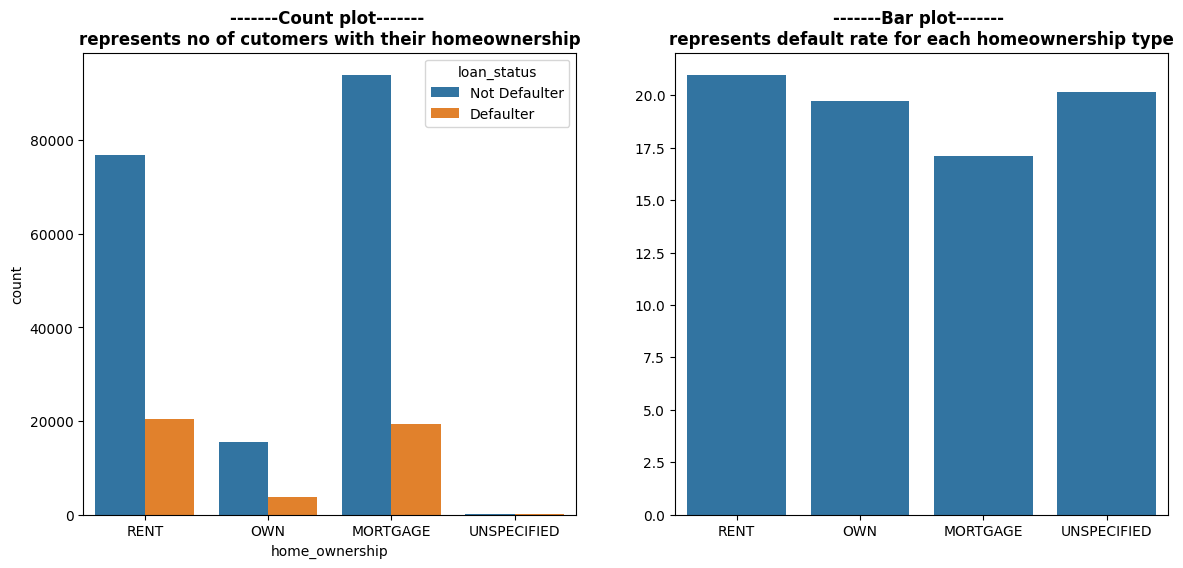

In [189]:
home_own_count = pd.crosstab(index = df['home_ownership'],
                             columns=df['loan_status'],)


plt.figure(figsize=(14,6))


plt.subplot(1,2,1)
print(f'The following table shows the count of home ownership and type of home ownership -----\n\n {home_own_count}')
sns.countplot(
    data=df,
    x="home_ownership",
    hue="loan_status"
)
plt.title('-------Count plot------- \nrepresents no of cutomers with their homeownership',fontweight = 'bold')


# Creating list for the second plot
home_own = df['home_ownership'].unique()
home_own
person_count = [int(df['home_ownership'][df['home_ownership'] == ownership ].count()) for ownership in home_own]
default_perc = [(int(home_own_count.loc[home_own[ownership],'Defaulter'])*100)/person_count[ownership] for ownership in range(4)]

home_own_default_rate = pd.DataFrame()
home_own_default_rate['Ownership'] = home_own
home_own_default_rate['Default Rate'] = default_perc

print(f'\n\nThe following table shows the default rate of home ownership -----\n\n {home_own_default_rate}')

# 2nd plot 
plt.subplot(1,2,2)
sns.barplot(x = home_own, y = default_perc)
plt.title('-------Bar plot------- \nrepresents default rate for each homeownership type',fontweight = 'bold')

plt.show()

Mortgage
- The household is in the process of buying the home with borrowed money (a mortgage loan). They live in the home and are considered owners, but they still owe payments to the bank or lender until the loan is fully repaid. The lender has a legal claim on the property until then.

### Interpretation

- The majority of borrowers either **rent** a home or have a **mortgage**, while relatively few borrowers own their homes.
- Across all home ownership categories, the number of **non-defaulters is significantly higher** than the number of defaulters.
- Borrowers with a **mortgage** have the **lowest default rate (17.09%)**, indicating comparatively lower credit risk.
- **Renters** have the **highest default rate (20.99%)**, followed by **UNSPECIFIED (20.18%)** and **OWN (19.75%)**.
- The **UNSPECIFIED** category contains very few observations; therefore, conclusions drawn from this category may not be reliable.
```

# Annual Income

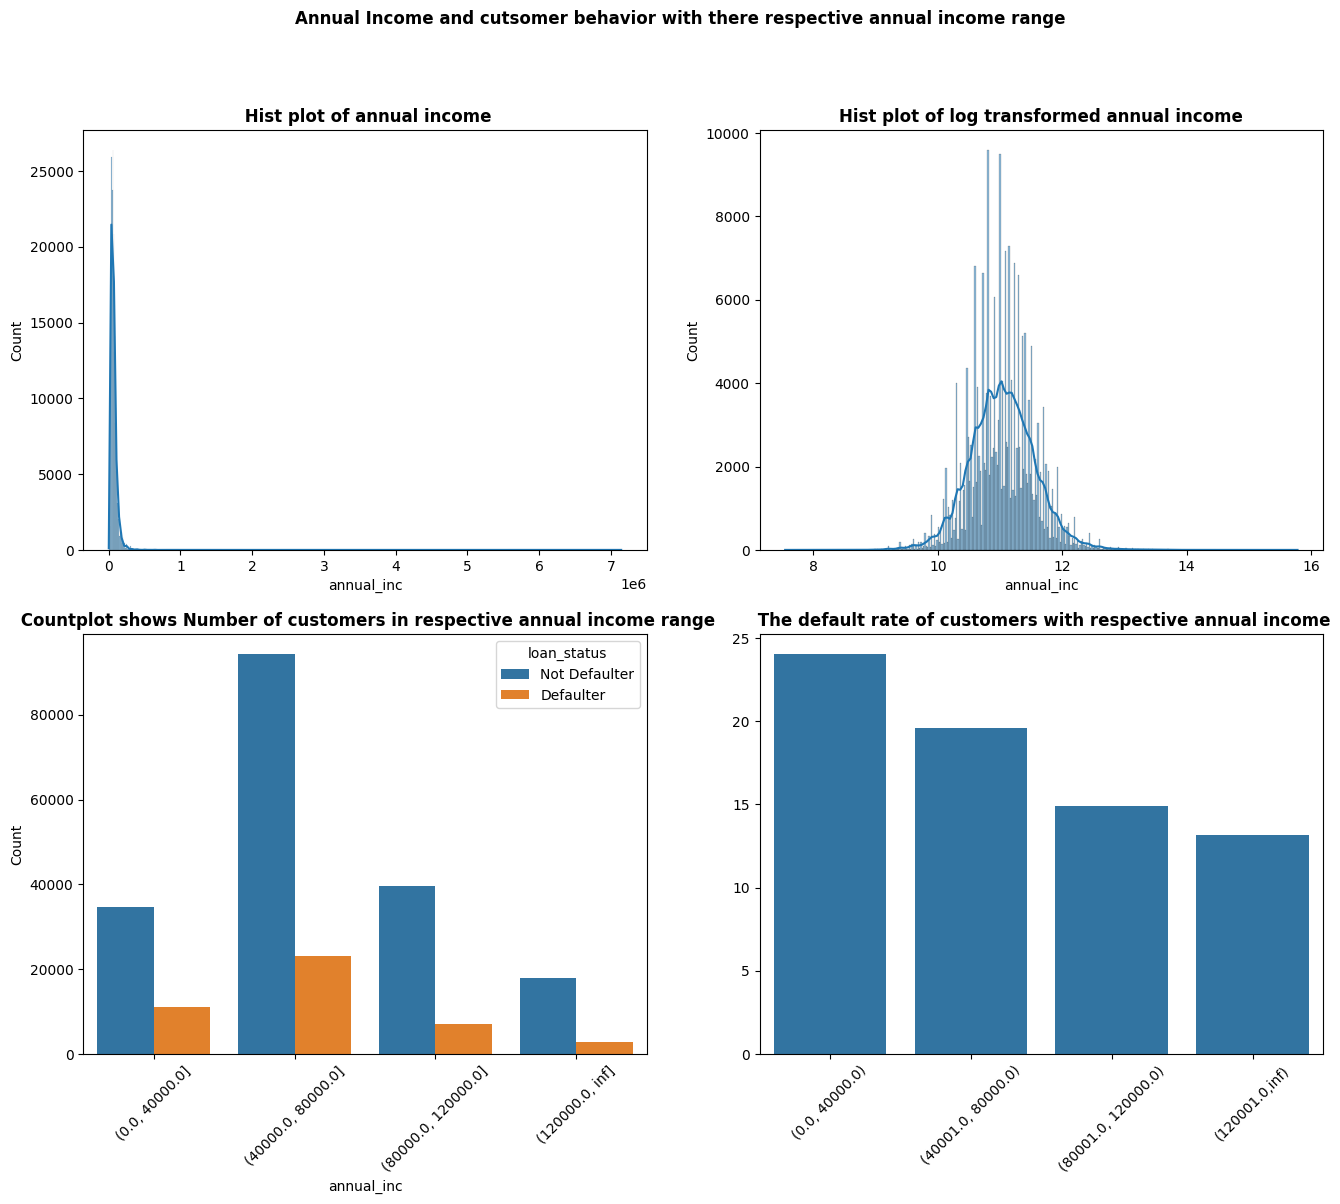

the default rate for intervals 
['(0.0, 40000.0)', '(40001.0, 80000.0)', '(80001.0, 120000.0)', '(120001.0,inf)'] 
are 
[24.04697854 19.61003118 14.90525954 13.15994166] respectively


In [ ]:
plt.figure(figsize=(16,12))

plt.subplot(2,2,1)
sns.histplot((df['annual_inc']),kde=True)
plt.title(' Hist plot of annual income',fontweight='bold')


plt.subplot(2,2,2)
sns.histplot(np.log(df['annual_inc']),kde=True)
plt.title('Hist plot of log transformed annual income',fontweight='bold')



# Plot 3 
df['annual_inc_range'] = pd.cut(df['annual_inc'],[0,40000,80000,120000,np.inf])
pd.cut(df['annual_inc'],[0,40000,80000,120000,np.inf]).value_counts()



plt.subplot(2,2,3)
sns.histplot(np.log(df['annual_inc']),kde=True)
plt.title(' Countplot shows Number of customers in respective annual income range',fontweight='bold')

sns.countplot(data = df, x = 'annual_inc_range',hue = 'loan_status')
plt.xticks(rotation = 45)


# plot 4 
plt.subplot(2,2,4)


# Creating a list of default rate for the corresponding annual income range
annual_inc_def = df.loc[ df['loan_status'] == 'Defaulter', :].groupby(['annual_inc_range'],observed=False)['loan_status'].count()
annual_inc_all_cust = df.groupby(['annual_inc_range'],observed=False)['loan_status'].count()

x_axis = ['(0.0, 40000.0)', '(40001.0, 80000.0)', '(80001.0, 120000.0)',
                  '(120001.0,inf)']
def_percet = annual_inc_def.values *100 / annual_inc_all_cust.values
def_percet


sns.barplot(x = x_axis, y= def_percet)
plt.title(" The default rate of customers with respective annual income", fontweight='bold')
plt.xticks(rotation = 45)

plt.suptitle("Annual Income and cutsomer behavior with there respective annual income range ",fontweight='black')
plt.show()


print(f"the default rate for intervals \n{x_axis} \nare \n{def_percet} respectively")

### 1. Histogram of Annual Income

- The `annual_inc` feature is **highly right-skewed**, indicating that most borrowers have relatively low annual incomes.
- A small number of borrowers have exceptionally high incomes, resulting in a long right tail.
- The presence of these extreme values makes the distribution highly imbalanced.

---

### 2. Histogram of Log-Transformed Annual Income

- Applying a **log transformation** significantly reduces the skewness of the annual income distribution.
- The transformed data is approximately **bell-shaped**, making it easier to visualize and analyze.
- This confirms that the original income feature was heavily influenced by extreme values.

---

### 3. Count Plot of Annual Income Groups

- The majority of borrowers belong to the **₹40,001–₹80,000** income group.
- The **₹0–₹40,000** and **₹80,001–₹1,20,000** groups contain a moderate number of borrowers.
- Borrowers with annual income **above ₹1,20,000** form the smallest income group.
- Across all income groups, the number of **non-defaulters exceeds the number of defaulters**.

---

### 4. Default Rate by Annual Income Group

- Borrowers earning **₹0–₹40,000** have the **highest default rate (24.05%)**.
- The default rate decreases steadily with increasing annual income:
  - **₹40,001–₹80,000:** **19.61%**
  - **₹80,001–₹1,20,000:** **14.91%**
  - **Above ₹1,20,000:** **13.16%**
- This indicates a **negative relationship between annual income and loan default**, suggesting that borrowers with higher incomes are generally less likely to default.

# Loan Purpose

In [191]:
# df.info()
df.purpose.value_counts()

purpose
debt_consolidation    133679
credit_card            46001
home_improvement       13415
other                  13229
major_purchase          5832
small_business          4632
car                     3448
medical                 2627
wedding                 1996
moving                  1841
house                   1494
vacation                1423
educational              419
renewable_energy         252
Name: count, dtype: int64

### Reason for Grouping Loan Purposes

The original `purpose` feature contains multiple categories, some of which have very few observations. To simplify the analysis and improve the readability of visualizations, similar loan purposes were grouped into broader business-oriented categories.

The grouping was based on the primary objective of the loan. For example, loans related to debt repayment were combined into **Debt Management**, while home-related purposes were grouped under **Home & Property**. This reduces category sparsity, makes comparisons more meaningful, and helps identify broader borrowing patterns without significantly losing information.

In [192]:
purpose_map = {
    'debt_consolidation': 'Debt Management',
    'credit_card': 'Debt Management',

    'home_improvement': 'Home & Property',
    'house': 'Home & Property',
    'moving': 'Home & Property',

    'medical': 'Personal Expenses',
    'vacation': 'Personal Expenses',
    'wedding': 'Personal Expenses',
    'other': 'Personal Expenses',

    'small_business': 'Business & Education',
    'educational': 'Business & Education',
    'renewable_energy': 'Business & Education',

    'car': 'Vehicle & Major Purchases',
    'major_purchase': 'Vehicle & Major Purchases'
}

df['purpose_group'] = df['purpose'].map(purpose_map)

 The following two graphs shows the count of total borrowers and their default rate


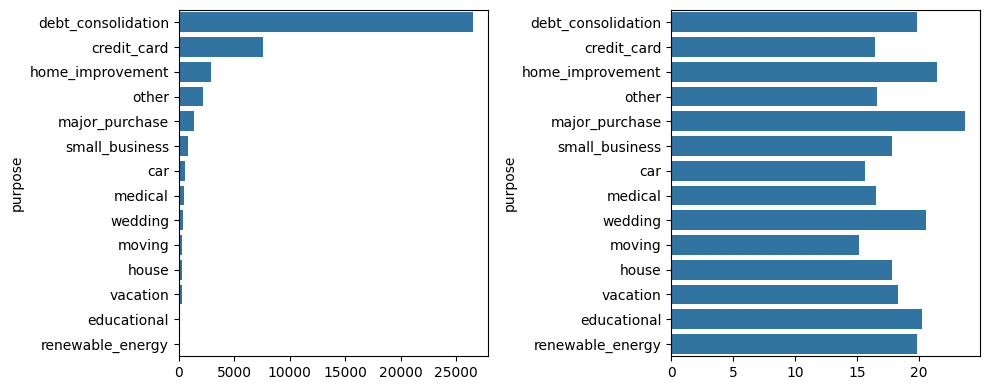

 The following two graphs shows the count of total borrowers and their default rate


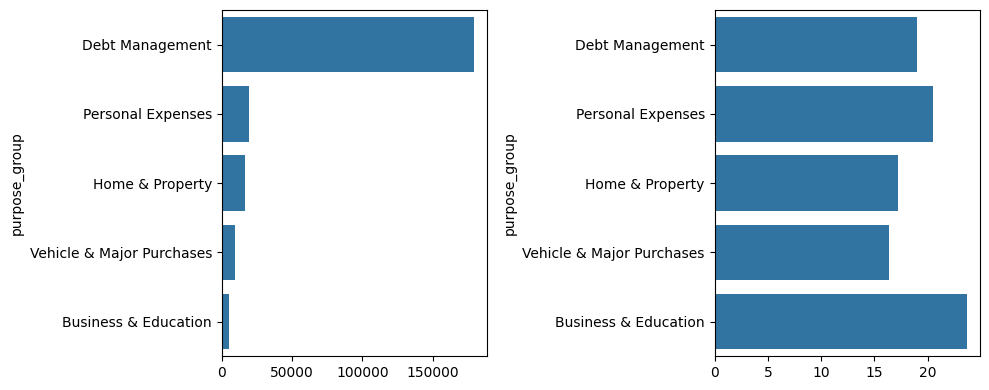

In [193]:
# plot one

print(' The following two graphs shows the count of total borrowers and their default rate')
plt.figure(figsize= (10,4))
plt.subplot(1,2,1)

overall_cust = df.purpose.value_counts()
defualter_cust = df[df['loan_status']=='Defaulter'].purpose.value_counts().values
def_rate = defualter_cust*100/overall_cust.values
sns.barplot(y =overall_cust.index , x = defualter_cust,orient = 'h')

plt.subplot(1,2,2)
sns.barplot(y =overall_cust.index , x = def_rate , orient = 'h')

plt.tight_layout()
plt.show()

# plot 2

print(' The following two graphs shows the count of total borrowers and their default rate')

plt.figure(figsize= (10,4))
plt.subplot(1,2,1)
sns.barplot(y = df.purpose_group.value_counts().index, x =df.purpose_group.value_counts().values)

plt.subplot(1,2,2)
loan_def = df[df['loan_status'] == 'Defaulter'].purpose_group.value_counts().values
def_rate_grouped_purpose = (loan_def*100)/df.purpose_group.value_counts().values
sns.barplot(y = df.purpose_group.value_counts().index, x = def_rate_grouped_purpose)

plt.tight_layout()
plt.show()


In [194]:
purpose_df = pd.DataFrame()
purpose_df['Grouped_purpose'] = df.purpose_group.value_counts().index
purpose_df['total_count'] = df.purpose_group.value_counts().values
purpose_df['def_count'] = loan_def
purpose_df['def_rate'] = def_rate_grouped_purpose
purpose_df

,Grouped_purpose,total_count,def_count,def_rate
0,Debt Management,179680,34055,18.953139
1,Personal Expenses,19275,3947,20.477302
2,Home & Property,16750,2889,17.247761
3,Vehicle & Major Purchases,9280,1520,16.379310
4,Business & Education,5303,1258,23.722421


In [195]:
purpose_df2 = pd.DataFrame()
purpose_df2['Grouped_purpose'] = df.purpose.value_counts().index
purpose_df2['total_count'] = df.purpose.value_counts().values
purpose_df2['def_count'] = defualter_cust
purpose_df2['def_rate'] = def_rate
purpose_df2

,Grouped_purpose,total_count,def_count,def_rate
0,debt_consolidation,133679,26480,19.808646
1,credit_card,46001,7575,16.467033
2,home_improvement,13415,2881,21.475960
3,other,13229,2200,16.630131
4,major_purchase,5832,1385,23.748285
5,small_business,4632,824,17.789292
6,car,3448,539,15.632251
7,medical,2627,434,16.520746
8,wedding,1996,410,20.541082
9,moving,1841,279,15.154807


### Interpretation

#### Individual Loan Purposes

- **Debt Consolidation** is the most common loan purpose, followed by **Credit Card** and **Home Improvement**.
- Loan purposes such as **Educational**, **Renewable Energy**, **Vacation**, and **House** have relatively few borrowers.
- Since the number of borrowers varies significantly across purposes, **default rate** is a more appropriate metric than the absolute number of defaulters for comparing risk.
- **Major Purchase (23.75%)** and **Home Improvement (21.48%)** exhibit the highest default rates among the major loan purposes.
- **Car (15.63%)**, **Moving (15.15%)**, and **Credit Card (16.47%)** have comparatively lower default rates.

---

#### Grouped Loan Purposes

- **Debt Management** (Debt Consolidation + Credit Card) accounts for the largest share of loan applications.
- **Business & Education** has the **highest default rate (23.72%)**, indicating that loans taken for business expansion or education are relatively riskier.
- **Personal Expenses** also show a relatively high default rate (**20.48%**).
- **Home & Property** has a moderate default rate (**17.25%**), while **Vehicle & Major Purchases** records the **lowest default rate (16.38%)** among all grouped categories.
- Grouping similar loan purposes simplifies the analysis while preserving the overall borrowing patterns and risk trends.

# Debt to Income ratio

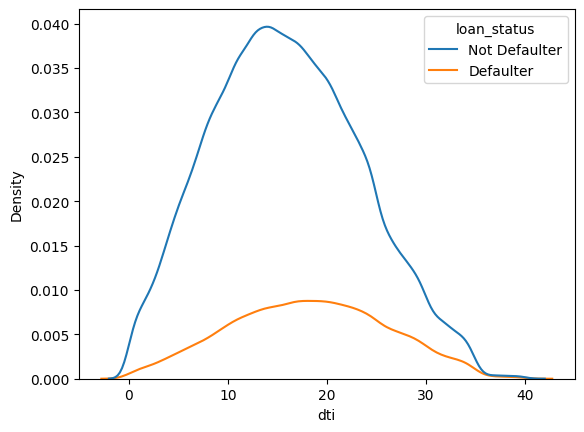

,loan_status,purpose_group,Mean_dti,SD_dti,Max_dti
0,Defaulter,Business & Education,13.775230,7.590792,37.75
1,Defaulter,Debt Management,18.946953,7.579844,39.98
2,Defaulter,Home & Property,15.576442,7.997437,39.17
3,Defaulter,Personal Expenses,16.443230,8.146402,39.66
4,Defaulter,Vehicle & Major Purchases,14.591224,8.242391,37.01
5,Not Defaulter,Business & Education,12.126735,7.534004,38.86
6,Not Defaulter,Debt Management,16.664589,7.347351,39.99
7,Not Defaulter,Home & Property,13.080730,7.662334,39.80
8,Not Defaulter,Personal Expenses,14.282096,7.836045,39.84
9,Not Defaulter,Vehicle & Major Purchases,12.225951,7.623254,39.99


In [196]:

sns.kdeplot(data = df, x= 'dti', hue ='loan_status')
plt.show()

df.groupby(['loan_status','purpose_group'])['dti'].aggregate(Mean_dti='mean', 
                                                             SD_dti = 'std',Max_dti = 'max').reset_index()


In [272]:
mean1 = df['dti'][df['loan_status'] == 'Defaulter'].describe()['mean']
mean2 = df['dti'][df['loan_status'] != 'Defaulter'].describe()['mean']
print(mean1,mean2)

from statsmodels.stats.weightstats import ztest

# for overall popn 
# ho : m1 = m2
# h1 : m1 != m2
g1 = np.array(df['dti'][df['loan_status'] == 'Defaulter'].values)
g2 = np.array(df['dti'][df['loan_status'] != 'Defaulter'].values)

z_stat, p_val = ztest(g1, g2)

print("z-statistic:", z_stat)
print("p-value:", p_val)


18.19218163914905 15.919926266886007
z-statistic: 56.103630408143076
p-value: 0.0


In [257]:
subgroups  = df.purpose_group.unique()

In [271]:
# for groupwise 

for i in  subgroups:
    g1 = np.array(df['dti'][(df['loan_status'] == 'Defaulter') & (df['purpose_group'] == i)].values)
    g2 = np.array(df['dti'][(df['loan_status'] != 'Defaulter') & (df['purpose_group'] == i)].values)

# m1 = for defualters and m2 = for non defaulters
# ho : m1 = m2
# h1 : m1 > m2
    z_stat, p_val = ztest(g1, g2, alternative='larger')

    print(f"For purpose group '{i}':")
    print(f"Mean DTI for Defaulters: {g1.mean():.2f}, Mean DTI for Non-Defaulters: {g2.mean():.2f}")
    print("z-statistic:", z_stat)
    print("p-value:", p_val)
    if p_val < 0.05:
        print("Reject the null hypothesis: There is a significant difference in means.")
    else:
        print("Fail to reject the null hypothesis: No significant difference in means.")
    print()


For purpose group 'Debt Management':
Mean DTI for Defaulters: 18.95, Mean DTI for Non-Defaulters: 16.66
z-statistic: 51.29594228302505
p-value: 0.0
Reject the null hypothesis: There is a significant difference in means.

For purpose group 'Vehicle & Major Purchases':
Mean DTI for Defaulters: 14.59, Mean DTI for Non-Defaulters: 12.23
z-statistic: 10.116537158830688
p-value: 2.333168470857332e-24
Reject the null hypothesis: There is a significant difference in means.

For purpose group 'Business & Education':
Mean DTI for Defaulters: 13.78, Mean DTI for Non-Defaulters: 12.13
z-statistic: 7.189544392568768
p-value: 3.2503940773701286e-13
Reject the null hypothesis: There is a significant difference in means.

For purpose group 'Personal Expenses':
Mean DTI for Defaulters: 16.44, Mean DTI for Non-Defaulters: 14.28
z-statistic: 15.325051747549557
p-value: 2.6006554213862306e-53
Reject the null hypothesis: There is a significant difference in means.

For purpose group 'Home & Property':
Mean

### Interpretation

#### DTI Distribution by Loan Status

- The **Debt-to-Income (DTI)** distribution for both defaulters and non-defaulters is approximately bell-shaped.
- Defaulters generally exhibit **higher DTI values** than non-defaulters, indicating that borrowers with a larger proportion of debt relative to their income are more likely to default.
- Most borrowers have a DTI between **10 and 25**, where the highest density is observed for both groups.
- The distribution gradually declines beyond a DTI of **30**, suggesting that relatively few borrowers have extremely high debt burdens.

---

#### Mean DTI Across Loan Purpose Groups

- Across all loan purpose groups, **defaulters consistently have a higher mean DTI** than non-defaulters.
- **Debt Management** loans have the highest average DTI for both defaulters (**18.95**) and non-defaulters (**16.66**), indicating that borrowers seeking debt-related loans generally carry higher existing debt.
- **Business & Education** and **Vehicle & Major Purchases** have the lowest average DTI among both defaulters and non-defaulters.
- The consistent difference in mean DTI between defaulters and non-defaulters suggests that **DTI is an important indicator of loan default risk**.

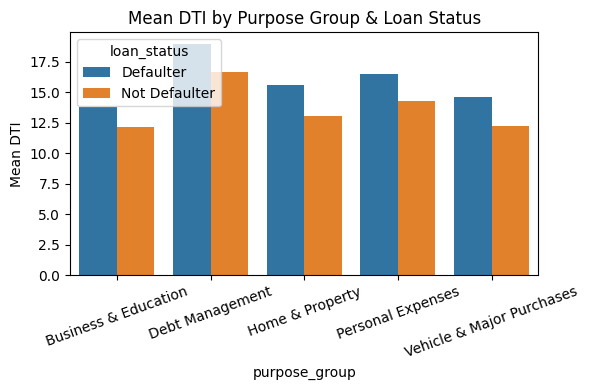

In [197]:
# Example summary table
purpose_df = (
    df.groupby(['loan_status', 'purpose_group'])['dti']
      .mean()
      .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=purpose_df,
    x='purpose_group',
    y='dti',
    hue='loan_status',
)

plt.title('Mean DTI by Purpose Group & Loan Status')
plt.xlabel('purpose_group')
plt.ylabel('Mean DTI')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Interpretation

- Across all purpose groups, **defaulters consistently have a higher mean Debt-to-Income (DTI) ratio** than non-defaulters, suggesting that borrowers with higher debt relative to their income are more likely to default.
- **Debt Management** loans have the highest mean DTI for both defaulters (**18.95**) and non-defaulters (**16.66**), indicating that borrowers seeking debt-related loans generally carry a higher debt burden.
- **Business & Education** and **Vehicle & Major Purchases** have comparatively lower mean DTI values than the other purpose groups.
- The consistent gap in mean DTI between defaulters and non-defaulters across all loan purpose groups suggests that **DTI is an important indicator of loan default risk**, irrespective of the purpose of the loan.

In [198]:
df.corr(numeric_only=True)['dti'][(df.corr(numeric_only=True)['dti'] > 0.15) | (df.corr(numeric_only=True)['dti'] < (-0.2))]

int_rate      0.170490
dti           1.000000
open_acc      0.312678
revol_bal     0.151242
revol_util    0.228204
total_acc     0.236140
Name: dti, dtype: float64

### Interpretation of `dti`

- `dti` shows a **weak positive correlation** with most numerical features, indicating that the debt-to-income ratio is relatively independent of other borrower characteristics.
- The highest correlation is observed with **`open_acc` (r = 0.313)**, suggesting that borrowers with more open credit accounts tend to have slightly higher debt-to-income ratios.
- `total_acc` (**r = 0.236**) and `revol_util` (**r = 0.228**) also exhibit weak positive correlations with `dti`, implying that borrowers with more credit accounts or higher credit utilization generally have slightly higher debt burdens.
- `int_rate` (**r = 0.170**) and `revol_bal` (**r = 0.151**) have only a weak association with `dti`.
- Overall, none of the correlations are strong, indicating that **`dti` provides unique information** and may serve as an important independent predictor of loan default.

# Delinquent_2yrs

#    delinq_2yrs                  

count    230288.000000
mean          0.243091
std           0.723969
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          29.000000
Name: delinq_2yrs, dtype: float64
delinq_2yrs
0.0     193916
1.0      25275
2.0       6932
3.0       2268
4.0        877
5.0        479
6.0        229
7.0        123
8.0         68
9.0         40
10.0        24
11.0        17
12.0        19
13.0         5
14.0         4
15.0         3
16.0         1
17.0         1
18.0         4
19.0         1
22.0         1
29.0         1
Name: count, dtype: int64


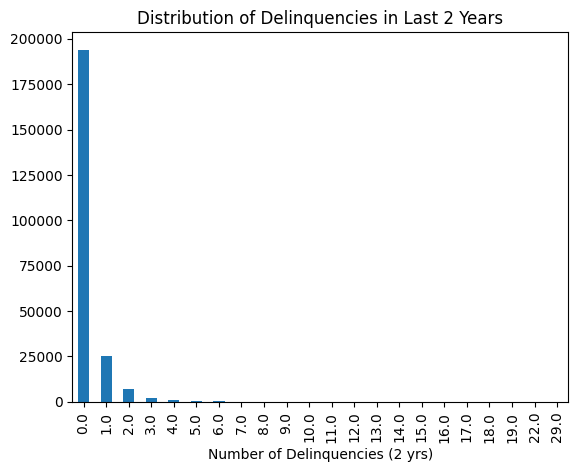

In [199]:
print(df['delinq_2yrs'].describe())
print(df['delinq_2yrs'].value_counts().sort_index())
df['delinq_2yrs'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Distribution of Delinquencies in Last 2 Years')
plt.xlabel('Number of Delinquencies (2 yrs)')
plt.show()

**Observation:** Delinquencies in the last 2 years are heavily right-skewed, with 84.2% of borrowers having zero recorded delinquencies and the remaining 15.8% spread thinly across 1 to 29 occurrences. The extreme tail (10+ delinquencies) represents single-digit or even single-occurrence counts, making them statistically negligible. Given this skew, a binary "has any delinquency" flag is likely more informative and statistically stable for comparing default rates than the raw count.

loan_status   Defaulter  Not Defaulter
delinq_2yrs                           
0.0           18.673549      81.326451
1.0           19.865480      80.134520
2.0           21.321408      78.678592
3.0           22.707231      77.292769
4.0           22.805017      77.194983
5.0           24.008351      75.991649
6.0           22.707424      77.292576
7.0           27.642276      72.357724
8.0           16.176471      83.823529
9.0           22.500000      77.500000
10.0          25.000000      75.000000
11.0          17.647059      82.352941
12.0          47.368421      52.631579
13.0          20.000000      80.000000
14.0          25.000000      75.000000
15.0          33.333333      66.666667
16.0           0.000000     100.000000
17.0         100.000000       0.000000
18.0          25.000000      75.000000
19.0           0.000000     100.000000
22.0           0.000000     100.000000
29.0           0.000000     100.000000


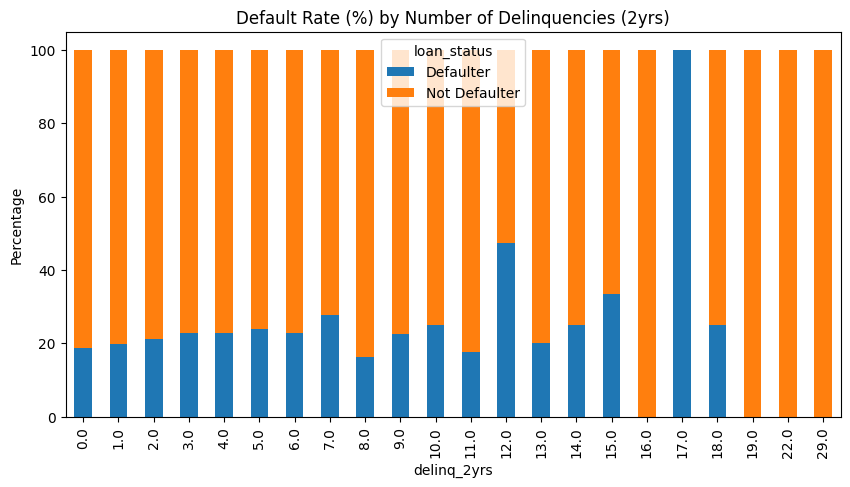

In [200]:
pct_table = pd.crosstab(df['delinq_2yrs'], df['loan_status'], normalize='index') * 100
print(pct_table)

pct_table.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Default Rate (%) by Number of Delinquencies (2yrs)')
plt.ylabel('Percentage')
plt.show()

**Observation:** Default rate shows a mild, gradual increase from ~18.7% (0 delinquencies) to ~22-24% (1-7 delinquencies), suggesting a real but modest relationship between delinquency history and default risk. Beyond 8-10 delinquencies, the chart becomes unreliable due to extremely small sample sizes (some categories contain fewer than 5 loans), producing erratic spikes (e.g., 47.4% at delinq_2yrs=12) and extreme values (0% or 100%) that reflect statistical noise rather than genuine risk patterns. The binary "any delinquency" flag is a more robust way to capture this relationship for modeling purposes.

loan_status  Defaulter  Not Defaulter
has_delinq                           
0            18.673549      81.326451
1            20.504784      79.495216


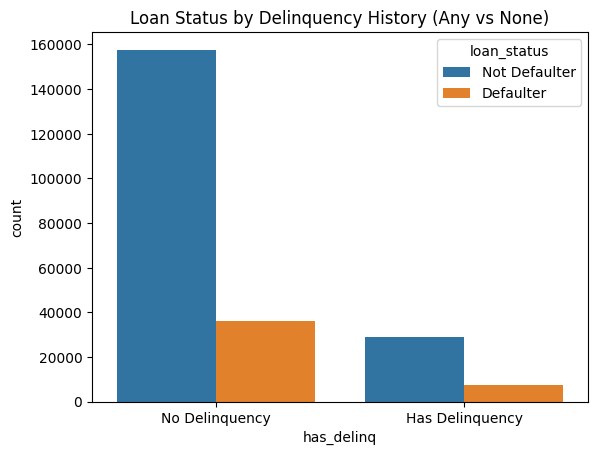

In [201]:
df['has_delinq'] = (df['delinq_2yrs'] > 0).astype(int)

print(df.groupby('has_delinq')['loan_status'].value_counts(normalize=True).unstack() * 100)

sns.countplot(data=df, x='has_delinq', hue='loan_status')
plt.title('Loan Status by Delinquency History (Any vs None)')
plt.xticks([0,1], ['No Delinquency', 'Has Delinquency'])
plt.show()

**Observation:** When collapsed into a binary flag, having any delinquency in the past 2 years is associated with only a modest increase in default rate (20.50% vs 18.67% for no delinquency) — a difference of less than 2 percentage points. This confirms `delinq_2yrs` is one of the weaker predictors identified in this EDA, contributing far less discriminative power than `grade`, `int_rate`, or `term`, despite intuitively sounding like a strong derogatory risk marker.

#  revolving credit balance

In [202]:
df['revol_bal'].describe()

count    2.302880e+05
mean     1.522987e+04
std      1.924105e+04
min      0.000000e+00
25%      5.901000e+03
50%      1.098750e+04
75%      1.907225e+04
max      1.746716e+06
Name: revol_bal, dtype: float64

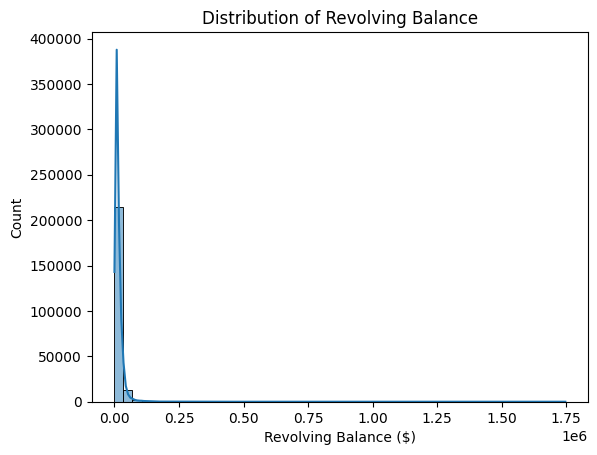

In [203]:
sns.histplot(df['revol_bal'], kde=True, bins=50)
plt.title('Distribution of Revolving Balance')
plt.xlabel('Revolving Balance ($)')
plt.show()

**Observation:** Revolving balance is heavily right-skewed (mean $15,230 vs median $10,988), with the vast majority of borrowers carrying balances under $20,000-30,000, but a small number of extreme outliers reaching as high as $1.75 million. This extreme skew makes raw histograms and boxplots largely unreadable, as the visualization scale is dominated by a handful of outliers rather than the typical borrower. A log transformation is necessary to meaningfully visualize and compare this variable, especially against `loan_status`.

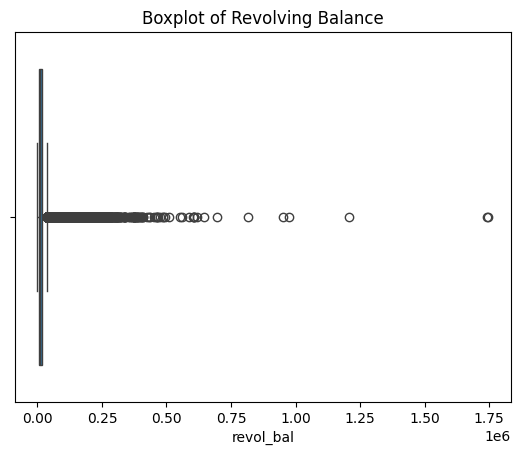

In [204]:
sns.boxplot(x=df['revol_bal'])
plt.title('Boxplot of Revolving Balance')
plt.show()

                  count          mean           std  min     25%      50%  \
loan_status                                                                 
Defaulter       43669.0  15169.794133  19250.795951  0.0  6266.0  11369.0   
Not Defaulter  186619.0  15243.921862  19238.787529  0.0  5820.0  10897.0   

                   75%        max  
loan_status                        
Defaulter      19208.0  1746716.0  
Not Defaulter  19046.0  1743266.0  


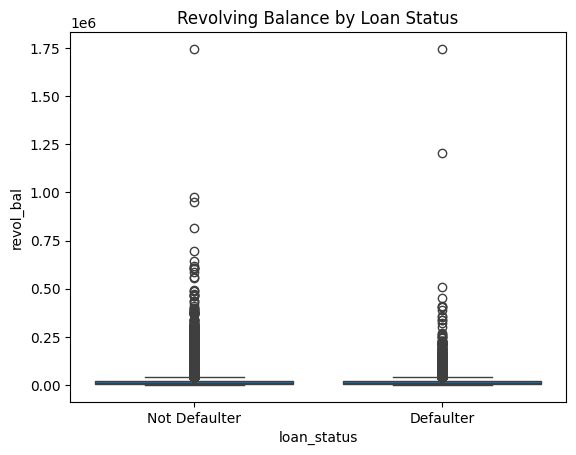

In [205]:
print(df.groupby('loan_status')['revol_bal'].describe())

sns.boxplot(data=df, x='loan_status', y='revol_bal')
plt.title('Revolving Balance by Loan Status')
plt.show()

**Observation:** Revolving balance shows essentially no relationship with default status — mean balances are nearly identical between defaulters ($15,169.79) and non-defaulters ($15,243.92), and even the boxplots are visually indistinguishable. This confirms that raw revolving balance, without context on credit limit, carries little discriminative power. The variable likely only becomes meaningful when expressed as a ratio of balance to credit limit (i.e., `revol_util`), which captures the borrower's true credit utilization rather than just the absolute debt amount.

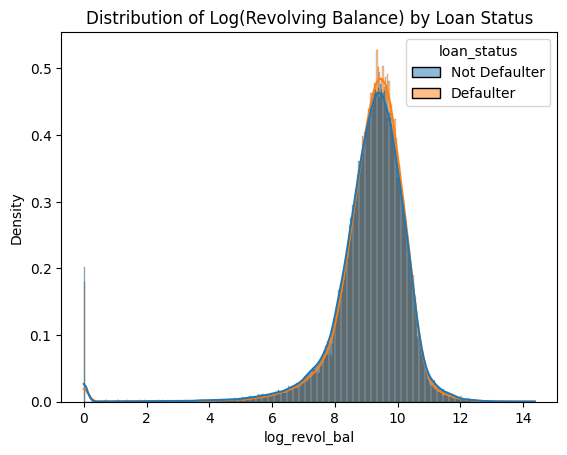

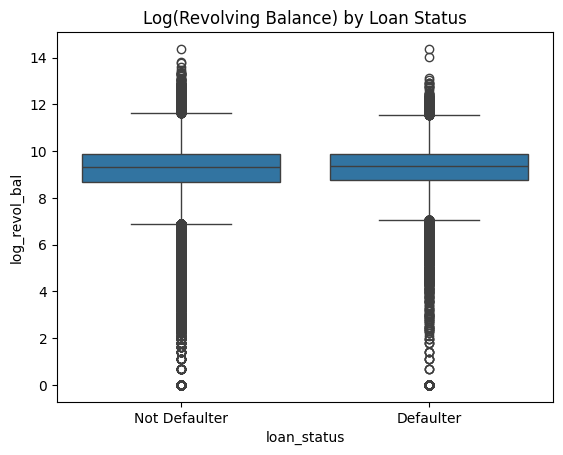

In [206]:
df['log_revol_bal'] = np.log1p(df['revol_bal'])  # log1p handles zero values safely

sns.histplot(data=df, x='log_revol_bal', hue='loan_status', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Log(Revolving Balance) by Loan Status')
plt.show()

sns.boxplot(data=df, x='loan_status', y='log_revol_bal')
plt.title('Log(Revolving Balance) by Loan Status')
plt.show()

**Observation:** After log-transforming `revol_bal`, the distribution reveals a roughly normal (bell-shaped) pattern, with a small distinct cluster near zero representing borrowers with no revolving balance. However, even on this corrected scale, the distributions for defaulters and non-defaulters remain nearly identical — both in the density plot and boxplot — confirming that `revol_bal` carries little to no discriminative power for predicting default, regardless of whether the raw or log-transformed version is used. This reinforces the earlier finding that revolving balance alone, without credit limit context, is not a meaningful risk indicator in this dataset.

            revol_bal  revol_util
revol_bal    1.000000    0.222232
revol_util   0.222232    1.000000


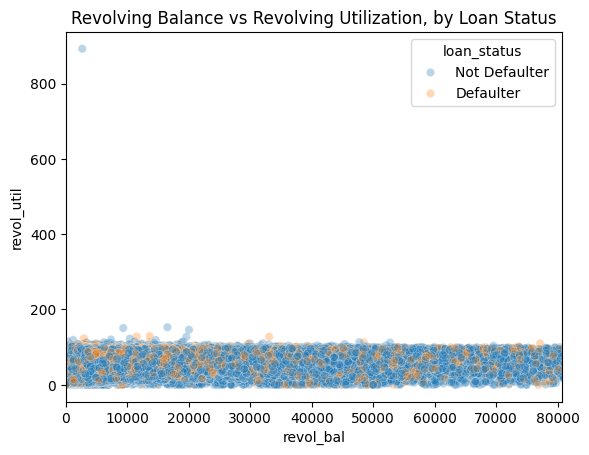

In [207]:
print(df[['revol_bal', 'revol_util']].corr())

sns.scatterplot(data=df, x='revol_bal', y='revol_util', hue='loan_status', alpha=0.3)
plt.title('Revolving Balance vs Revolving Utilization, by Loan Status')
plt.xlim(0, df['revol_bal'].quantile(0.99))  # cap x-axis to avoid extreme outliers squashing the view
plt.show()

**Observation:** Revolving balance and revolving utilization show only a weak correlation (0.222), confirming they capture distinct dimensions of credit usage rather than redundant information. The scatter plot shows no visible separation between defaulters and non-defaulters across this balance-utilization relationship, and a single extreme outlier (~900% utilization) was identified, likely indicating a data quality issue worth addressing in the cleaning/imputation phase rather than a genuine extreme value.

# Revolving Utilization

In [208]:
df['revol_util'].describe()

count    230288.000000
mean         54.797788
std          24.773385
min           0.000000
25%          37.000000
50%          56.500000
75%          74.400000
max         892.300000
Name: revol_util, dtype: float64

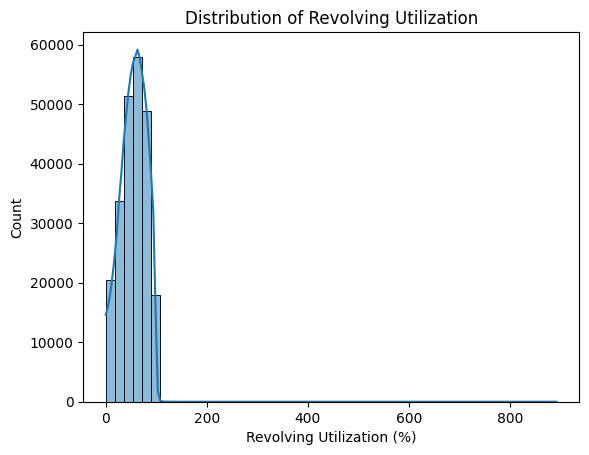

In [209]:
sns.histplot(df['revol_util'], kde=True, bins=50)
plt.title('Distribution of Revolving Utilization')
plt.xlabel('Revolving Utilization (%)')
plt.show()

**Observation:** Revolving utilization shows a fairly symmetric, bell-shaped distribution centered around 55-57%, with mean (54.80%) and median (56.50%) closely aligned. While the theoretical maximum should be near 100%, the data contains an extreme outlier at 892.30%, consistent with the data quality concern flagged earlier — this should be investigated and likely capped or treated as an error during the imputation/cleaning phase, as it distorts the visual scale of the histogram.

                  count       mean        std  min   25%   50%   75%    max
loan_status                                                                
Defaulter       43669.0  59.575915  23.483782  0.0  43.5  61.8  78.1  129.4
Not Defaulter  186619.0  53.679702  24.933785  0.0  35.5  55.2  73.3  892.3


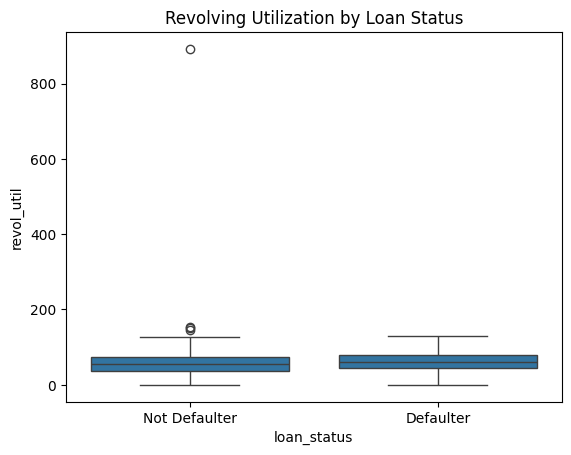

In [210]:
print(df.groupby('loan_status')['revol_util'].describe())

sns.boxplot(data=df, x='loan_status', y='revol_util')
plt.title('Revolving Utilization by Loan Status')
plt.show()

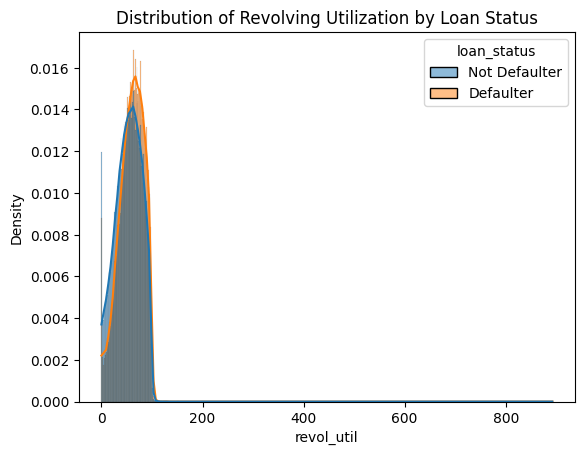

In [211]:
sns.histplot(data=df, x='revol_util', hue='loan_status', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Revolving Utilization by Loan Status')
plt.show()

**Observation:** Revolving utilization shows a real, consistent difference between defaulters and non-defaulters — defaulters carry meaningfully higher utilization (mean: 59.58% vs 53.68%; median: 61.80% vs 55.20%), a gap of roughly 6 percentage points across the distribution. This confirms that `revol_util` — unlike raw `revol_bal` — captures genuine credit stress signal, since maxed-out credit lines relative to limit are a more meaningful risk indicator than absolute balance alone. The extreme outlier (892.3% utilization) belongs to the non-defaulter group, reinforcing that it is likely a data quality artifact rather than a true risk case.

loan_status     Defaulter  Not Defaulter
revol_util_bin                          
0-20%           11.258339      88.741661
20-40%          15.472301      84.527699
40-60%          18.729124      81.270876
60-80%          21.199208      78.800792
80-100%         23.576895      76.423105
100%+           30.303030      69.696970


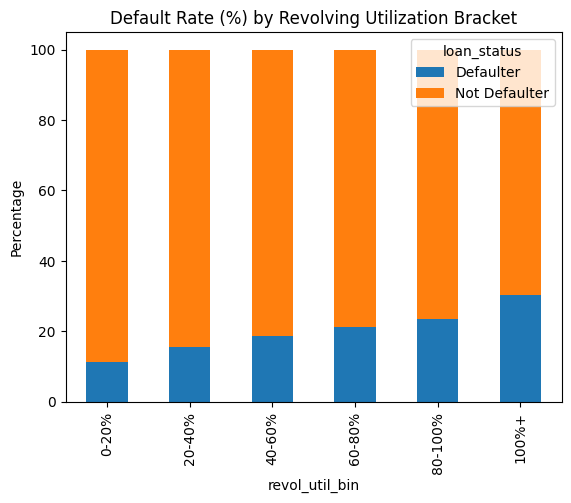

In [212]:
bins = [0, 20, 40, 60, 80, 100, 1000]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '100%+']
df['revol_util_bin'] = pd.cut(df['revol_util'], bins=bins, labels=labels)

pct_table = pd.crosstab(df['revol_util_bin'], df['loan_status'], normalize='index') * 100
print(pct_table)

pct_table.plot(kind='bar', stacked=True)
plt.title('Default Rate (%) by Revolving Utilization Bracket')
plt.ylabel('Percentage')
plt.show()

**Observation:** Revolving utilization shows a clean, monotonic relationship with default rate, rising from 11.26% (0-20% utilization) to 30.30% (100%+ utilization) — nearly a 3x increase in risk across the full range. The relationship is consistent across all brackets, with a particularly sharp jump for borrowers exceeding their credit limit (100%+), suggesting being over-limit is a qualitatively more severe risk signal than simply approaching it. This positions `revol_util` as a stronger predictor than initially estimated from the mean/median comparison alone, closer in strength to `term` than to the weaker mid-tier variables.

# Open Account

In [213]:
df['open_acc'].describe()

count    230288.000000
mean         10.830977
std           4.811105
min           0.000000
25%           7.000000
50%          10.000000
75%          13.000000
max          76.000000
Name: open_acc, dtype: float64

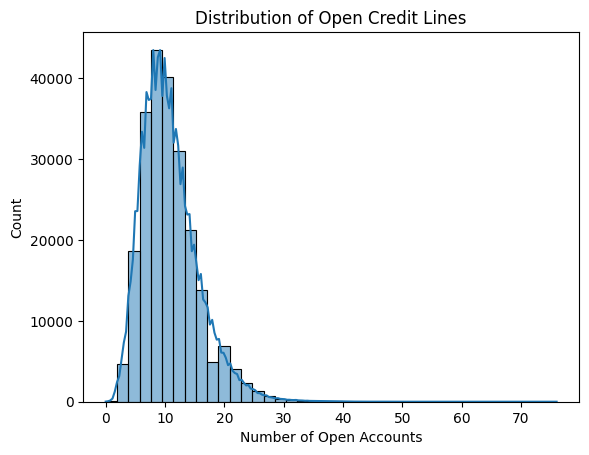

In [214]:
sns.histplot(df['open_acc'], kde=True, bins=40)
plt.title('Distribution of Open Credit Lines')
plt.xlabel('Number of Open Accounts')
plt.show()

**Observation:** The number of open credit accounts is right-skewed, with most borrowers holding between 7 and 13 open accounts (mean: 10.83, median: 10.0). The distribution peaks around 8-10 accounts and tapers into a long, sparse tail extending up to 76, representing a small number of borrowers with unusually extensive credit histories. The data appears clean with no obvious quality issues.

                  count       mean       std  min  25%   50%   75%   max
loan_status                                                             
Defaulter       43669.0  11.015182  4.910603  0.0  8.0  10.0  14.0  76.0
Not Defaulter  186619.0  10.787873  4.786514  0.0  7.0  10.0  13.0  58.0


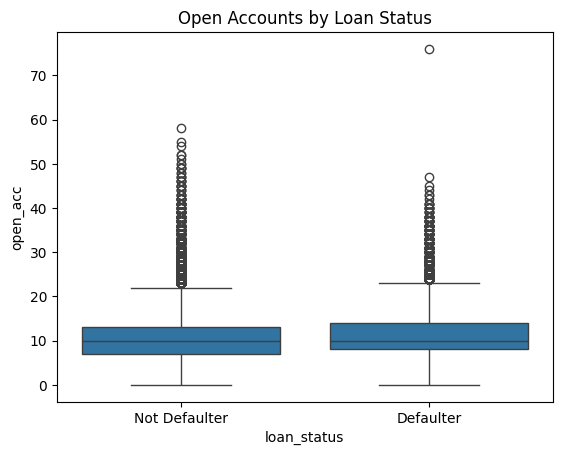

In [215]:
print(df.groupby('loan_status')['open_acc'].describe())

sns.boxplot(data=df, x='loan_status', y='open_acc')
plt.title('Open Accounts by Loan Status')
plt.show()

**Observation:** Number of open credit accounts shows virtually no relationship with default status — mean values are nearly identical (11.02 for defaulters vs 10.79 for non-defaulters), and the median is exactly the same (10.0) for both groups. The boxplots show almost complete overlap, confirming that simply having more or fewer open accounts is not a meaningful predictor of default risk on its own in this dataset.


loan_status   Defaulter  Not Defaulter
open_acc_bin                          
0-5           17.882433      82.117567
5-10          18.528157      81.471843
10-15         19.435163      80.564837
15-20         19.550395      80.449605
20-25         20.687257      79.312743
25+           22.401848      77.598152


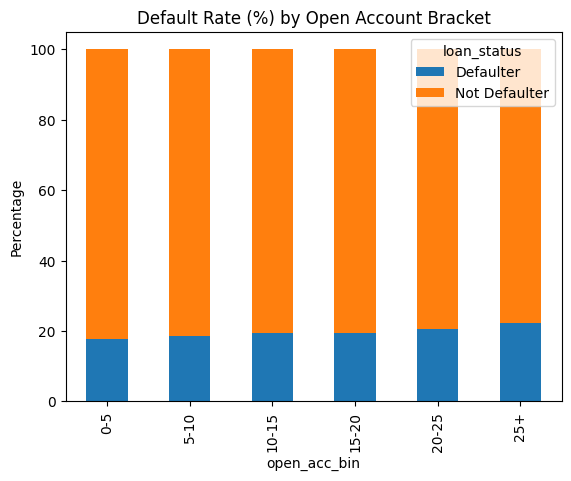

In [216]:
bins = [0, 5, 10, 15, 20, 25, 100]
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25+']
df['open_acc_bin'] = pd.cut(df['open_acc'], bins=bins, labels=labels)

pct_table = pd.crosstab(df['open_acc_bin'], df['loan_status'], normalize='index') * 100
print(pct_table)

pct_table.plot(kind='bar', stacked=True)
plt.title('Default Rate (%) by Open Account Bracket')
plt.ylabel('Percentage')
plt.show()

**Observation:** While the mean and median comparison initially suggested no relationship between open accounts and default status, the binned view reveals a mild but consistent monotonic trend: default rate rises from 17.88% (0-5 open accounts) to 22.40% (25+ accounts), an increase of about 4.5 percentage points. This is a real but weak signal — far smaller than the effect seen in `grade`, `int_rate`, `term`, or `revol_util` — suggesting that having more open credit lines is mildly associated with elevated default risk, but is not a strong standalone predictor.

# Total Account

In [217]:
df['total_acc'].describe()

count    230288.000000
mean         24.797362
std          11.655175
min           1.000000
25%          16.000000
50%          23.000000
75%          32.000000
max         150.000000
Name: total_acc, dtype: float64

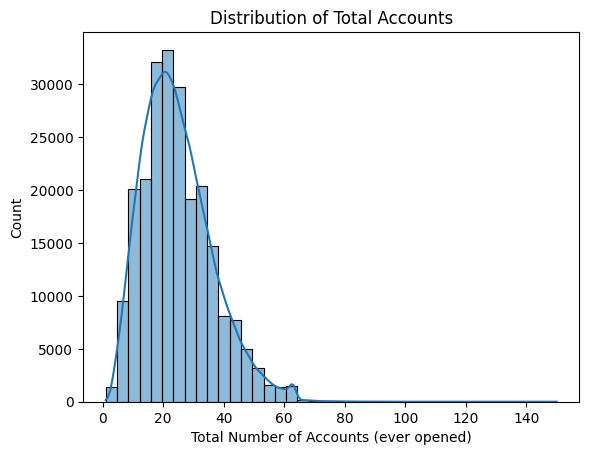

In [218]:
sns.histplot(df['total_acc'], kde=True, bins=40)
plt.title('Distribution of Total Accounts')
plt.xlabel('Total Number of Accounts (ever opened)')
plt.show()

### Observation

- Most borrowers have **15–30 total credit accounts**, with a median of **23**.
- The distribution is **right-skewed**, indicating a few borrowers have a very high number of accounts.
- The data shows **potential outliers**, with the maximum reaching **150 accounts**.
- Overall, `total_acc` is **not normally distributed** and is concentrated around **20–25 accounts**.
```

                  count       mean        std  min   25%   50%   75%    max
loan_status                                                                
Defaulter       43669.0  24.161556  11.519976  1.0  16.0  23.0  31.0   94.0
Not Defaulter  186619.0  24.946142  11.681621  1.0  16.0  23.0  32.0  150.0


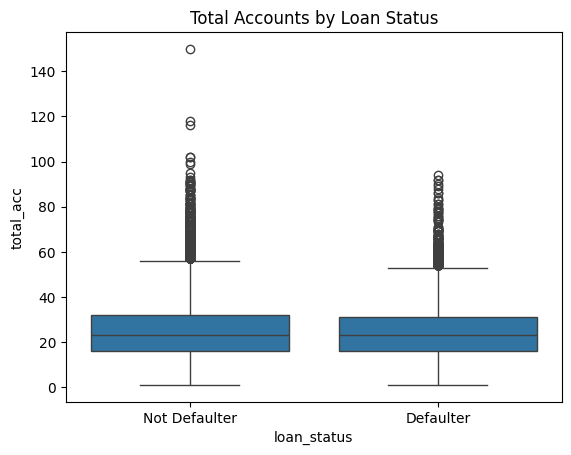

In [219]:
print(df.groupby('loan_status')['total_acc'].describe())

sns.boxplot(data=df, x='loan_status', y='total_acc')
plt.title('Total Accounts by Loan Status')
plt.show()

### Observation

- The distribution of **`total_acc`** is similar for both **Defaulters** and **Non-Defaulters**, with median values around **23 accounts**.
- **Non-Defaulters** have a slightly higher average number of total accounts (**24.95**) than **Defaulters** (**24.16**).
- Both groups show **many high-value outliers**, indicating a few borrowers have an unusually large number of credit accounts.
- Overall, **`total_acc` alone does not clearly distinguish defaulters from non-defaulters**.
```

loan_status    Defaulter  Not Defaulter
total_acc_bin                          
0-10           20.783163      79.216837
10-20          19.863587      80.136413
20-30          18.726368      81.273632
30-40          17.752787      82.247213
40-50          17.804817      82.195183
50+            16.652446      83.347554


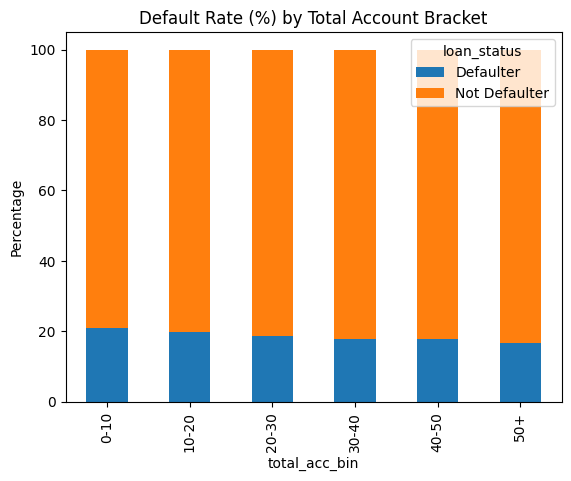

In [220]:
bins = [0, 10, 20, 30, 40, 50, 200]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50+']
df['total_acc_bin'] = pd.cut(df['total_acc'], bins=bins, labels=labels)

pct_table = pd.crosstab(df['total_acc_bin'], df['loan_status'], normalize='index') * 100
print(pct_table)

pct_table.plot(kind='bar', stacked=True)
plt.title('Default Rate (%) by Total Account Bracket')
plt.ylabel('Percentage')
plt.show()

### Observation

- The **default rate decreases slightly** as the total number of accounts increases.
- Borrowers with **0–10 accounts** have the **highest default rate (20.78%)**, while those with **50+ accounts** have the **lowest default rate (16.65%)**.
- The differences across account brackets are **small**, suggesting that **`total_acc` has only a weak relationship with loan default**.
```

# Public Records


count    230288.000000
mean          0.132782
std           0.417611
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          11.000000
Name: pub_rec, dtype: float64
pub_rec
0.0     203978
1.0      23469
2.0       2003
3.0        528
4.0        164
5.0         79
6.0         35
7.0         16
8.0          5
9.0          5
10.0         5
11.0         1
Name: count, dtype: int64


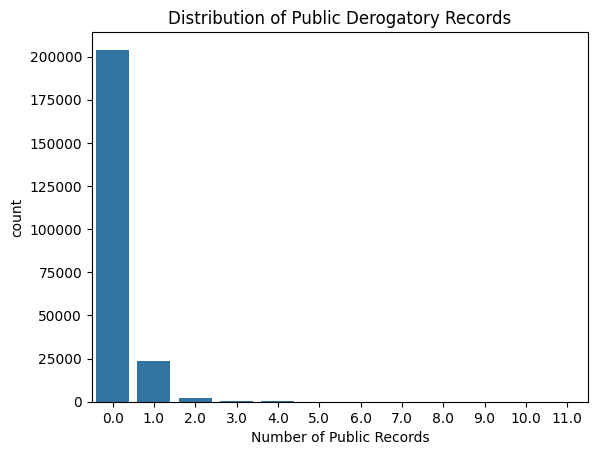

In [221]:
print(df['pub_rec'].describe())
print(df['pub_rec'].value_counts().sort_index())
sns.countplot(data=df, x='pub_rec')
plt.title('Distribution of Public Derogatory Records')
plt.xlabel('Number of Public Records')
plt.show()

### Observation

- The **`pub_rec`** variable is **highly right-skewed**, with the majority of borrowers having **0 public derogatory records**.
- The **median is 0**, and **75% of borrowers also have 0 public records**, indicating that public records are rare.
- Only a **small proportion of borrowers have one or more public records**, with very few having values above **3**.
- The variable contains **extreme values (up to 11)**, but these occur very infrequently.
```

loan_status  Defaulter  Not Defaulter
has_pub_rec                          
0            18.862328      81.137672
1            19.741543      80.258457


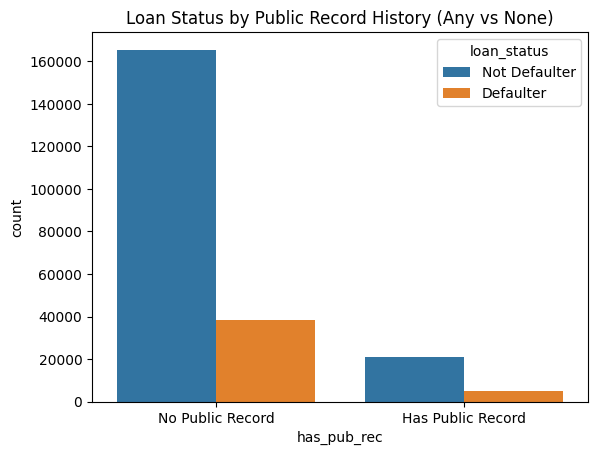

In [222]:
df['has_pub_rec'] = (df['pub_rec'] > 0).astype(int)

print(df.groupby('has_pub_rec')['loan_status'].value_counts(normalize=True).unstack() * 100)

sns.countplot(data=df, x='has_pub_rec', hue='loan_status')
plt.title('Loan Status by Public Record History (Any vs None)')
plt.xticks([0,1], ['No Public Record', 'Has Public Record'])
plt.show()

### Observation

- Borrowers **with at least one public record** have a **slightly higher default rate (19.74%)** than those with **no public records (18.86%)**.
- Most borrowers **do not have any public records**, and the majority in both groups are **non-defaulters**.
- The difference in default rates is **small**, suggesting that **public record history alone is not a strong predictor of loan default**.
```

In [223]:
pct_table = pd.crosstab(df['pub_rec'], df['loan_status'], normalize='index') * 100
print(pct_table)

loan_status  Defaulter  Not Defaulter
pub_rec                              
0.0          18.862328      81.137672
1.0          19.532149      80.467851
2.0          21.717424      78.282576
3.0          18.750000      81.250000
4.0          24.390244      75.609756
5.0          26.582278      73.417722
6.0          22.857143      77.142857
7.0          31.250000      68.750000
8.0           0.000000     100.000000
9.0          40.000000      60.000000
10.0          0.000000     100.000000
11.0          0.000000     100.000000


### Observation

- The **default rate generally increases** as the number of public derogatory records (`pub_rec`) increases.
- Borrowers with **4–9 public records** show noticeably **higher default rates** (around **24%–40%**) compared to those with **0–3 records**.
- The values for **8, 10, and 11 public records** are based on **very few observations**, so they are **not reliable for drawing conclusions**.
- Overall, having **more public derogatory records is associated with a higher likelihood of loan default**, although higher record counts are rare.

# Date Type Columns
- Analysing loan issue date 
- analysing customers total loan duration before fully paide or changed off

In [224]:
loan = df.copy()

loan['issue_d'] = pd.to_datetime('01-'+ loan.issue_d)

loan = loan.sort_values('issue_d')

C:\Users\Dev\AppData\Local\Temp\ipykernel_24100\1518295696.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan['issue_d'] = pd.to_datetime('01-'+ loan.issue_d)


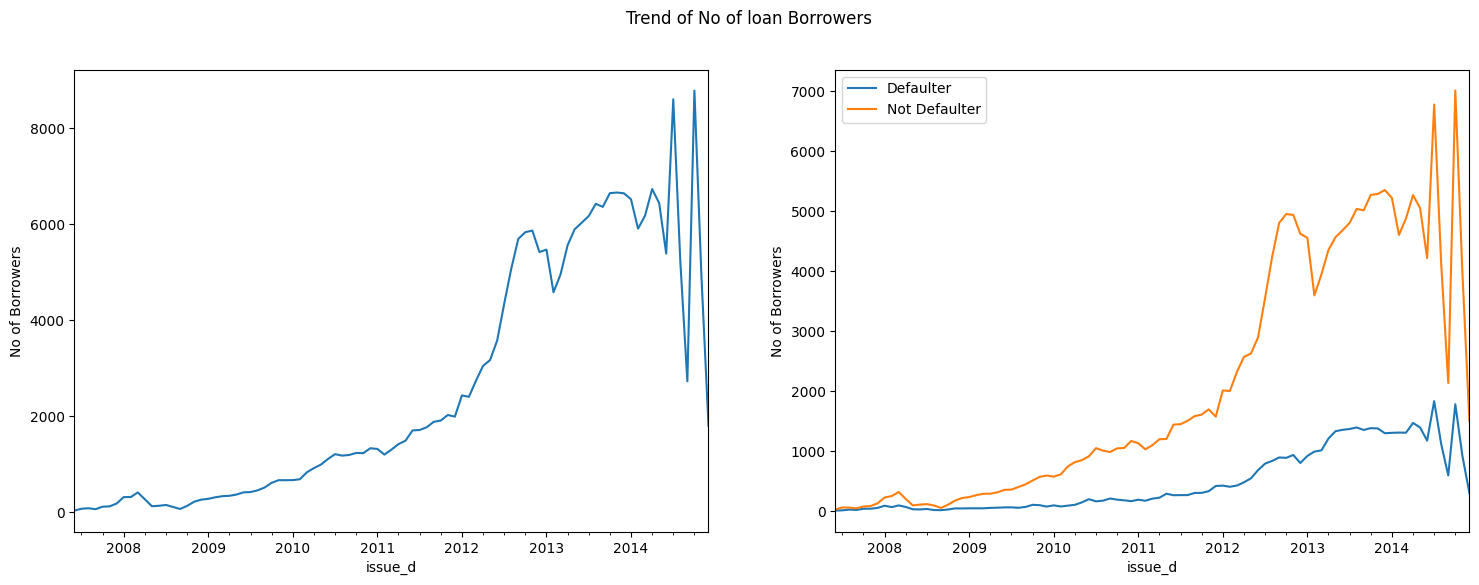

In [225]:
plt.figure(figsize=(18,6))

plt.suptitle('Trend of No of loan Borrowers')

plt.subplot(1,2,1)
loan.groupby('issue_d')['loan_amnt'].count().plot()
plt.ylabel('No of Borrowers')

plt.subplot(1,2,2)
loan[loan['loan_status'] == 'Defaulter'].groupby('issue_d')['loan_amnt'].count().plot()
loan[loan['loan_status'] == 'Not Defaulter'].groupby('issue_d')['loan_amnt'].count().plot()
plt.legend(['Defaulter', 'Not Defaulter'])
plt.ylabel('No of Borrowers')
plt.show()

### Interpretation

- The total number of loan borrowers exhibits a **strong upward trend** from **2007 to 2014**, indicating substantial growth in lending activity over the years.
- Loan issuance increased gradually until **2012**, followed by a more rapid increase during **2012–2014**.
- Throughout the entire period, the number of **non-defaulters consistently remained higher** than the number of defaulters, indicating that most borrowers successfully repaid their loans.
- Although the number of defaulters increased over time, this trend largely mirrors the overall growth in loan applications rather than indicating a significant increase in default risk.
- Some fluctuations are observed during **2014**, suggesting variations in monthly borrowing activity toward the end of the study period.
- Overall, the trend demonstrates a steady expansion in loan issuance while maintaining a relatively stable repayment pattern.

In [226]:
df[['last_pymnt_d', 'next_pymnt_d','loan_status']]

,last_pymnt_d,next_pymnt_d,loan_status
0,Jan-15,NaN,Not Defaulter
1,Apr-13,NaN,Defaulter
2,Jun-14,NaN,Not Defaulter
3,Jan-15,NaN,Not Defaulter
4,Jan-15,NaN,Not Defaulter
...,...,...,...
230283,May-14,NaN,Defaulter
230284,Nov-14,NaN,Defaulter
230285,Sep-15,NaN,Not Defaulter
230286,Dec-14,NaN,Defaulter


# Converting last_payment_d to dattime

In [227]:
loan.last_pymnt_d = pd.to_datetime('01-' +loan.last_pymnt_d)

C:\Users\Dev\AppData\Local\Temp\ipykernel_24100\856179422.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan.last_pymnt_d = pd.to_datetime('01-' +loan.last_pymnt_d)


In [228]:
loan = loan.reset_index(drop=True)

In [229]:
loan['customer_time_with_bank'] = (loan.last_pymnt_d - loan.issue_d)
loan['customer_time_with_bank_months'] = ((loan.last_pymnt_d - loan.issue_d).astype(str).str.split().str[0].astype(int)/30).astype(int)                # assuming 30 days - months

In [230]:
loan[ (loan.issue_d > loan.last_pymnt_d)] [['issue_d','last_pymnt_d']]    # inconsistent entries
# Your issue date > than loan payment date 
idx = loan[ (loan.issue_d > loan.last_pymnt_d)] [['issue_d','last_pymnt_d']].index
loan = loan.drop(index = idx)

In [231]:
loan[loan['term'] == '60 months']

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,annual_inc_range,purpose_group,has_delinq,log_revol_bal,revol_util_bin,open_acc_bin,total_acc_bin,has_pub_rec,customer_time_with_bank,customer_time_with_bank_months


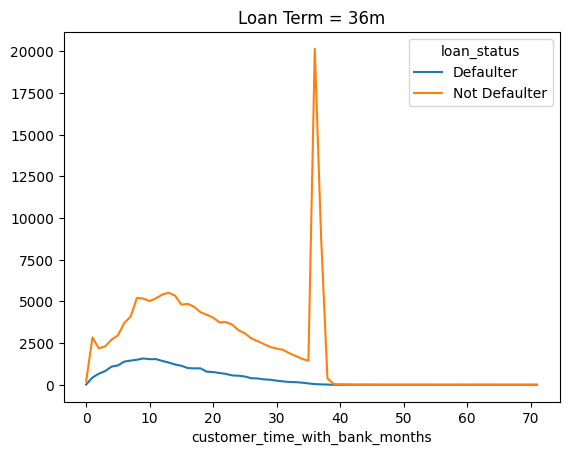

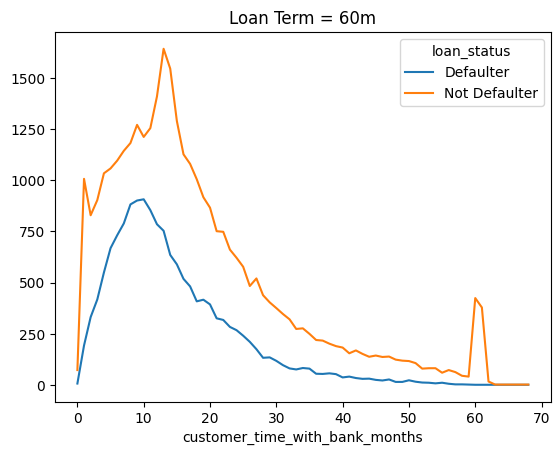

In [232]:

pd.crosstab(index=loan[loan.term == ' 36 months'].customer_time_with_bank_months , columns = loan[loan.term == ' 36 months'].loan_status).plot()
plt.title('Loan Term = 36m')
pd.crosstab(index=loan[loan.term == ' 60 months'].customer_time_with_bank_months , columns = loan[loan.term == ' 60 months'].loan_status).plot()
plt.title('Loan Term = 60m')
plt.show()

### Interpretation

- The borrower-bank relationship duration is strongly influenced by the **loan term**.
- For **36-month loans**, a pronounced peak is observed at **36 months**, indicating that a large number of borrowers completed their loans according to the scheduled repayment period.
- Similarly, **60-month loans** exhibit a distinct peak at **60 months**, reflecting borrowers who completed longer-term loans.
- Borrowers whose relationship duration **extends beyond the scheduled loan term** are predominantly **defaulters**. This suggests that loans exceeding their contractual tenure are more likely to experience delayed repayment, collection activities, or default.
- Apart from these peaks, the number of borrowers gradually decreases as the relationship duration increases.
- The spikes at **36** and **60** months are expected because these are the standard loan terms offered by the lender and do not indicate any issue with the data.
- Overall, the borrower-bank relationship duration closely follows the contractual loan tenure, while durations extending beyond the loan term are more commonly associated with defaulted loans.
S

In [233]:
loan[loan['customer_time_with_bank_months'] == 36]['term'].value_counts()
# loan[loan['customer_time_with_bank_months'] == 60]['term'].value_counts()

term
36 months    20199
60 months      273
Name: count, dtype: int64

In [234]:
loan[['customer_time_with_bank_months','term','loan_status']].sample(10)

,customer_time_with_bank_months,term,loan_status
119251,20,36 months,Not Defaulter
19810,36,36 months,Not Defaulter
66319,25,36 months,Defaulter
46571,3,36 months,Not Defaulter
181802,15,36 months,Defaulter
15413,31,60 months,Not Defaulter
188043,8,36 months,Not Defaulter
77677,32,36 months,Not Defaulter
218206,11,36 months,Not Defaulter
38126,30,36 months,Not Defaulter


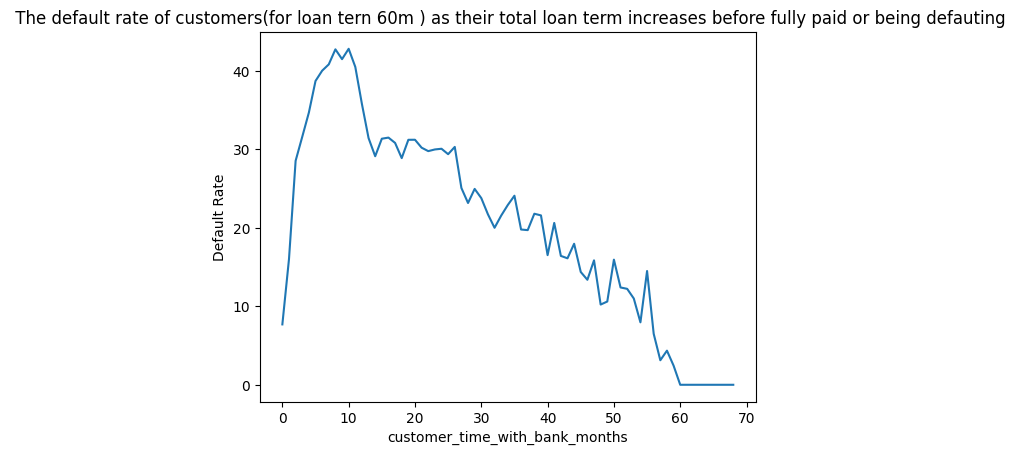

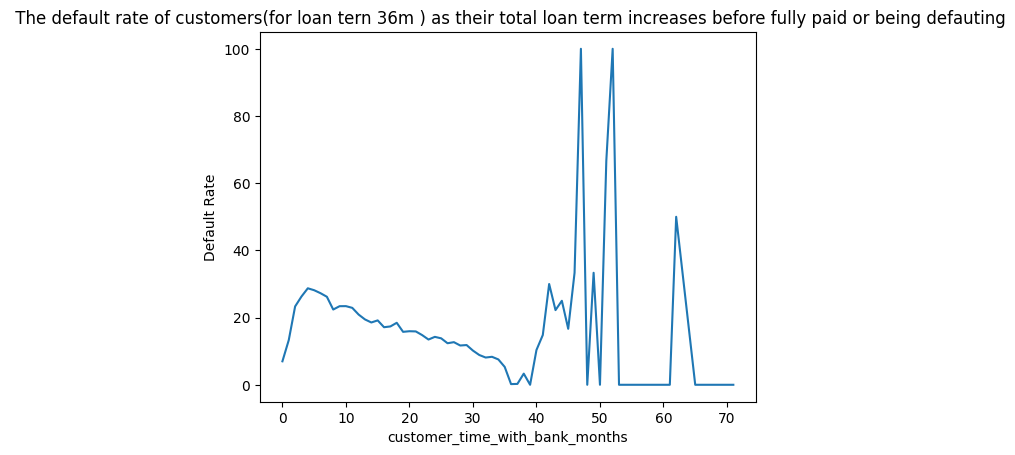

In [235]:
(pd.crosstab(index=loan[loan.term == ' 60 months'].customer_time_with_bank_months , columns = loan[loan.term == ' 60 months'].loan_status)['Defaulter']*100/pd.crosstab(index=loan[loan.term == ' 60 months'].customer_time_with_bank_months , columns = loan[loan.term == ' 60 months'].loan_status).sum(axis=1)).plot()
plt.ylabel('Default Rate')
plt.title(' The default rate of customers(for loan tern 60m ) as their total loan term increases before fully paid or being defauting')
plt.show()

(pd.crosstab(index=loan[loan.term == ' 36 months'].customer_time_with_bank_months , columns = loan[loan.term == ' 36 months'].loan_status)['Defaulter']*100/pd.crosstab(index=loan[loan.term == ' 36 months'].customer_time_with_bank_months , columns = loan[loan.term == ' 36 months'].loan_status).sum(axis=1)).plot()
plt.ylabel('Default Rate')
plt.title(' The default rate of customers(for loan tern 36m ) as their total loan term increases before fully paid or being defauting')
plt.show()

In [236]:
loan[(loan['term'] == ' 36 months') & (loan['customer_time_with_bank_months'] > 36)]['customer_time_with_bank_months'].describe()
loan[(loan['term'] == ' 36 months') & (loan['customer_time_with_bank_months'] > 36)]['customer_time_with_bank_months'].value_counts()

customer_time_with_bank_months
37    8834
38     392
39      42
40      29
41      27
44      12
42      10
46       9
43       9
49       6
45       6
53       3
51       3
62       2
59       2
60       1
68       1
67       1
69       1
48       1
71       1
50       1
65       1
52       1
55       1
61       1
57       1
47       1
Name: count, dtype: int64

In [237]:
loan[(loan['term'] == ' 36 months') & (loan['customer_time_with_bank_months'] > 36)]['loan_status'].value_counts()

loan_status
Not Defaulter    9337
Defaulter          62
Name: count, dtype: int64

### Interpretation

#### Loan Term = 36 Months

- The default rate increases during the initial few months, reaching approximately **25–30%** within the first **5–7 months**.
- After the initial peak, the default rate gradually declines as borrowers continue making timely repayments, indicating that longer repayment history is associated with a lower probability of default.
- The sharp spikes observed **after 40 months** should be interpreted with caution. Since the contractual loan term is **36 months**, very few borrowers remain beyond this period. Consequently, even a small number of defaults can produce extremely high default rates (up to 100%), making these values statistically unreliable.
- Overall, borrowers who successfully continue repayment beyond the early months are progressively less likely to default.

---

#### Loan Term = 60 Months

- The default rate rises rapidly during the first **8–10 months**, reaching a peak of approximately **43%**.
- After the initial peak, the default rate steadily decreases throughout the remaining loan period.
- By the end of the 60-month term, the default rate approaches **zero**, indicating that borrowers who remain active until the scheduled maturity are highly likely to complete repayment successfully.
- Unlike the 36-month loans, the trend for 60-month loans is relatively smooth because a larger number of borrowers remain active throughout the loan tenure.

---

#### Overall Observation

- For both **36-month** and **60-month** loans, the **highest default risk occurs during the early repayment period**.
- As borrowers continue making regular repayments, the probability of default gradually decreases.
- This suggests that **a longer successful repayment history is associated with lower default risk**.
- Default-rate estimates beyond the contractual loan term should be interpreted cautiously due to the very small number of remaining borrowers.